# Анализ репертуара TRA/TRB методом операций над множествами и счётного анализа

**Мышиная модель аллотрансплантации BALB/c → C57BL/6, α- и β-цепи Т-клеточного рецептора**

Эта тетрадь воспроизводит первичный анализ, положенный в основу статьи. Она реализует две независимые аналитические линии для приоритизации донор-реактивных V-сегментов:

1. **Операции над множествами точных клонотипов (диаграммы Венна).** Клонотип определяется как пара `(CDR3aa, V)` (режим `aaV`). Сравнение групп выполняется через пересечения множеств клонотипов и подсчёт локализации V-сегментов в области «только g1».
2. **Дифференциальный счётный анализ (edgeR / DESeq2 / точный тест Фишера).** Клонотип моделируется как счётная величина; различия обилия между группами оцениваются обобщёнными линейными моделями с контролем частоты ложных открытий.

**Группы:** g1 — интактные реципиенты BALB/c; g2 — доноры C57BL/6; g3 — сингенный перенос костного мозга; g4 — контроль кондиционирования; g5 — аллогенный перенос костного мозга; g6 — аллогенный перенос костного мозга с тимусом донора.

**Приоритетные кандидаты по итогам двух линий:** TRAV4-2, TRAV13-1, семейство TRAV7D, TRAV9-4.

> Независимая проверка этих результатов методами вложения последовательностей (библиотека mirpy) вынесена в отдельную тетрадь `mirpy_analysis.ipynb`; сводное сопоставление трёх линий — в `results_summary.ipynb`.

---

### Структура тетради

| Раздел | Содержание |
|---|---|
| Запуск / TRA / TRB | Построение счётных таблиц клонотипов, диаграммы Венна пересечений |
| Венн и V оставшихся | Локализация V-сегментов в областях пересечений |
| Таблицы убывания | Ранжирование V-сегментов по доле в «только g1» |
| Сравнение TRA/TRB (Дженсен–Шеннон, Спирмен) | Метрики сходства репертуаров |
| EdgeR-блок | Дифференциальный счётный анализ: edgeR, DESeq2, тест Фишера |
| Сравнение методов | Сопоставление Fisher / edgeR / DESeq2, консенсусные клонотипы |


## Запуск

In [ ]:
# !pip install matplotlib-venn
# !pip install adjustText

In [ ]:
import os
import pandas as pd
from IPython.display import Image, display
import seaborn as sns
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
from matplotlib.patches import Circle
from matplotlib_venn import venn3
from adjustText import adjust_text

#REPSEQ_PATH = os.path.join(os.path.expanduser("~"), "soft", "repseq")
REPSEQ_PATH = "/home/mkomkova/projects/mice_transplant_2025/soft/repseq"  # внешний repseq
if REPSEQ_PATH not in sys.path:
    sys.path.insert(0, REPSEQ_PATH)

sys.path.append(REPSEQ_PATH)
from repseq import io as repseqio
from repseq import mixcr as mx
from repseq import slurm
from repseq import clonosets as cl
from repseq import stats
from repseq import clone_filter as clf
from repseq import intersections
from repseq import clustering
from repseq import logo
from repseq import vdjtools
from repseq import diffexp

WORKING_DIR = "/projects/mice_transplant_2025/test_run/"
MIXCR_DIR = os.path.join(WORKING_DIR, "mixcr")
RESULTS_DIR = os.path.join(WORKING_DIR, "results")
RAW_DATA_DIR = "/projects/mice_transplant_2025/raw/"
METADATA_FILENAME = "/projects/mice_transplant_2025/metadata_mice_transplant.csv"
SAMPLE_LIST_FILENAME = os.path.join(WORKING_DIR, "sample_table.csv")
TABLE_REPORT_FILENAME = os.path.join(WORKING_DIR, "table_report.csv")
os.makedirs(WORKING_DIR, exist_ok=True)
metadata = pd.read_csv(METADATA_FILENAME)
metadata["sample_id_old"] = metadata["chain"] + "-" + metadata["sample_no"].astype(str)
metadata = metadata.drop(columns="chain")

clonosets = pd.read_csv(os.path.join(WORKING_DIR, "clonosets_mice_transplant_2025_df.csv"))
clonosets = clonosets.rename(columns={"sample_id": "sample_id_old"}).merge(metadata).drop(columns="sample_id_old")
clonosets = clonosets[['sample_id'] + [col for col in clonosets.columns if col != 'sample_id']].sort_values(by="sample_id").reset_index(drop=True)
clonosets_tra_g1 = clonosets.query("chain == 'TRA' and group_no in ['g1']").query("sample_id != 'g1_m3_thymus_cd8_80_alpha'").sort_values(by="umi_func")
clonosets_tra_g2 = clonosets.query("chain == 'TRA' and group_no in ['g2']").sort_values(by="umi_func")
clonosets_tra_g3 = clonosets.query("chain == 'TRA' and group_no in ['g3']").sort_values(by="umi_func")
clonosets_tra_g4 = clonosets.query("chain == 'TRA' and group_no in ['g4']").sort_values(by="umi_func")
clonosets_tra_g5 = clonosets.query("chain == 'TRA' and group_no in ['g5']").query("sample_id != 'g5_m1_spleen_cd4_93_alpha' and sample_id != 'g5_m4_thymus_cd8_100_alpha'").sort_values(by="umi_func")
clonosets_tra_g6_allo = clonosets.query("chain == 'TRA' and group_no in ['g6'] and source != 'thymus'").sort_values(by="umi_func")
clonosets_tra_g6_auto = clonosets.query("chain == 'TRA' and group_no in ['g6'] and source != 'allothymus'").sort_values(by="umi_func")
clonosets_tra_g6 = clonosets.query("chain == 'TRA' and group_no in ['g6']").sort_values(by="umi_func")

clonosets_trb_g1 = clonosets.query("chain == 'TRB' and group_no in ['g1']").sort_values(by="umi_func")
clonosets_trb_g2 = clonosets.query("chain == 'TRB' and group_no in ['g2']").sort_values(by="umi_func")
clonosets_trb_g3 = clonosets.query("chain == 'TRB' and group_no in ['g3']").sort_values(by="umi_func")
clonosets_trb_g4 = clonosets.query("chain == 'TRB' and group_no in ['g4']").sort_values(by="umi_func")
clonosets_trb_g5 = clonosets.query("chain == 'TRB' and group_no in ['g5']").sort_values(by="umi_func")
clonosets_trb_g6_allo = clonosets.query("chain == 'TRB' and group_no in ['g6'] and source != 'thymus'").sort_values(by="umi_func")
clonosets_trb_g6_auto = clonosets.query("chain == 'TRB' and group_no in ['g6'] and source != 'allothymus'").sort_values(by="umi_func")
clonosets_trb_g6 = clonosets.query("chain == 'TRB' and group_no in ['g6']").sort_values(by="umi_func")

In [ ]:
# ct_g1_aaV = intersections.count_table(
#     clonosets_tra_g1,
#     #cl_filter=downsample_filter_30000,
#     overlap_type="aaV",
#     mismatches=0
# )

# ct_g2_aaV = intersections.count_table(
#     clonosets_tra_g2,
#     #cl_filter=downsample_filter_30000,
#     overlap_type="aaV",
#     mismatches=0
# )

# ct_g5_aaV = intersections.count_table(
#     clonosets_tra_g5,
#     #cl_filter=downsample_filter_30000,
#     overlap_type="aaV",
#     mismatches=0
# )

# ct_g6_auto_aaV = intersections.count_table(
#     clonosets_tra_g6_auto,
#     overlap_type="aaV",
#     mismatches=0
# )

# ct_g6_allo_aaV = intersections.count_table(
#     clonosets_tra_g6_allo,
#     overlap_type="aaV",
#     mismatches=0
# )

# ct_g6_aaV = intersections.count_table(
#     clonosets_tra_g6,
#     #cl_filter=downsample_filter_30000,
#     overlap_type="aaV",
#     mismatches=0
# )

# def count_table_index_to_df(ct, overlap_type):
#     idx = list(ct.index)

#     if overlap_type == "aaV":
#         df = pd.DataFrame(idx, columns=["cdr3aa", "v"])
#         df["clone_id"] = list(zip(df["cdr3aa"], df["v"]))
#         return df

#     if overlap_type == "aaVJ":
#         df = pd.DataFrame(idx, columns=["cdr3aa", "v", "j"])
#         df["clone_id"] = list(zip(df["cdr3aa"], df["v"], df["j"]))
#         return df

#     raise ValueError("overlap_type must be 'aaV' or 'aaVJ'")


# def get_clone_set(ct, overlap_type):
#     return set(ct.index)


# def get_clone_presence_df(ct, overlap_type):
#     sample_cols = list(ct.columns)

#     if overlap_type == "aaV":
#         df = pd.DataFrame(list(ct.index), columns=["cdr3aa", "v"], index=ct.index)
#     elif overlap_type == "aaVJ":
#         df = pd.DataFrame(list(ct.index), columns=["cdr3aa", "v", "j"], index=ct.index)
#     else:
#         raise ValueError("overlap_type must be 'aaV' or 'aaVJ'")

#     df["n_samples"] = (ct[sample_cols] > 0).sum(axis=1)
#     df["total_count"] = ct[sample_cols].sum(axis=1)
#     df = df.reset_index(drop=True)

#     return df


# def subtract_clone_sets(ct_a, ct_b, overlap_type):
#     set_a = set(ct_a.index)
#     set_b = set(ct_b.index)

#     only_a = sorted(set_a - set_b)

#     if overlap_type == "aaV":
#         df = pd.DataFrame(only_a, columns=["cdr3aa", "v"])
#         df["clone_id"] = list(zip(df["cdr3aa"], df["v"]))
#         return df

#     if overlap_type == "aaVJ":
#         df = pd.DataFrame(only_a, columns=["cdr3aa", "v", "j"])
#         df["clone_id"] = list(zip(df["cdr3aa"], df["v"], df["j"]))
#         return df

#     raise ValueError("overlap_type must be 'aaV' or 'aaVJ'")


# # --------------------------------------------------
# # 5. Списки клонов для каждой группы: aaV
# # --------------------------------------------------

# clones_g1_aaV_df = count_table_index_to_df(ct_g1_aaV, "aaV")
# clones_g2_aaV_df = count_table_index_to_df(ct_g2_aaV, "aaV")
# clones_g5_aaV_df = count_table_index_to_df(ct_g5_aaV, "aaV")
# clones_g6_auto_aaV_df = count_table_index_to_df(ct_g6_auto_aaV, "aaV")
# clones_g6_allo_aaV_df = count_table_index_to_df(ct_g6_allo_aaV, "aaV")
# clones_g6_aaV_df = count_table_index_to_df(ct_g6_aaV, "aaV")

# # presence/abundance summary
# clones_g1_aaV_presence = get_clone_presence_df(ct_g1_aaV, "aaV")
# clones_g2_aaV_presence = get_clone_presence_df(ct_g2_aaV, "aaV")
# clones_g5_aaV_presence = get_clone_presence_df(ct_g5_aaV, "aaV")
# clones_g6_auto_aaV_presence = get_clone_presence_df(ct_g6_auto_aaV, "aaV")
# clones_g6_allo_aaV_presence = get_clone_presence_df(ct_g6_allo_aaV, "aaV")
# clones_g6_aaV_presence = get_clone_presence_df(ct_g6_aaV, "aaV")

# # --------------------------------------------------
# # 7. Разности множеств: aaV
# # --------------------------------------------------

# clones_g1_minus_g5_aaV_df = subtract_clone_sets(ct_g1_aaV, ct_g5_aaV, "aaV")
# clones_g2_minus_g5_aaV_df = subtract_clone_sets(ct_g2_aaV, ct_g5_aaV, "aaV")

# clones_g5_minus_g1_aaV_df = subtract_clone_sets(ct_g5_aaV, ct_g1_aaV, "aaV")
# clones_g5_minus_g2_aaV_df = subtract_clone_sets(ct_g5_aaV, ct_g2_aaV, "aaV")

## TRA

In [ ]:
ct_g1_aaV_tra = intersections.count_table(
    clonosets_tra_g1,
    #cl_filter=downsample_filter_30000,
    overlap_type="aaV",
    mismatches=0
)

ct_g2_aaV_tra = intersections.count_table(
    clonosets_tra_g2,
    #cl_filter=downsample_filter_30000,
    overlap_type="aaV",
    mismatches=0
)

ct_g3_aaV_tra = intersections.count_table(
    clonosets_tra_g3,
    #cl_filter=downsample_filter_30000,
    overlap_type="aaV",
    mismatches=0
)

ct_g4_aaV_tra = intersections.count_table(
    clonosets_tra_g4,
    #cl_filter=downsample_filter_30000,
    overlap_type="aaV",
    mismatches=0
)

ct_g5_aaV_tra = intersections.count_table(
    clonosets_tra_g5,
    #cl_filter=downsample_filter_30000,
    overlap_type="aaV",
    mismatches=0
)

# ct_g6_auto_aaV_tra = intersections.count_table(
#     clonosets_tra_g6_auto,
#     overlap_type="aaV",
#     mismatches=0
# )

# ct_g6_allo_aaV_tra = intersections.count_table(
#     clonosets_tra_g6_allo,
#     overlap_type="aaV",
#     mismatches=0
# )

ct_g6_aaV_tra = intersections.count_table(
    clonosets_tra_g6,
    #cl_filter=downsample_filter_30000,
    overlap_type="aaV",
    mismatches=0
)

In [ ]:
def plot_double_triple_venn_like(
    center_set,
    left_top_set,
    left_bottom_set,
    right_top_set,
    right_bottom_set,
    center_label,
    left_top_label,
    left_bottom_label,
    right_top_label,
    right_bottom_label,
    title=None,
    save_path=None
):
    """
    5-circle venn-like plot:

    Левая тройка: left_top, center, left_bottom
    Правая тройка: right_top, center, right_bottom

    Cross-пересечения между левой и правой тройкой
    НЕ рисуются.
    """

    center_set = set(center_set)
    left_top_set = set(left_top_set)
    left_bottom_set = set(left_bottom_set)
    right_top_set = set(right_top_set)
    right_bottom_set = set(right_bottom_set)

    # ---------------------------
    # ЛЕВАЯ тройка
    # ---------------------------
    left_top_only = left_top_set - (center_set | left_bottom_set)
    left_bottom_only = left_bottom_set - (center_set | left_top_set)
    left_top_left_bottom_only = (left_top_set & left_bottom_set) - center_set
    center_left_top_only = (center_set & left_top_set) - left_bottom_set
    center_left_bottom_only = (center_set & left_bottom_set) - left_top_set
    left_triple = center_set & left_top_set & left_bottom_set

    # ---------------------------
    # ПРАВАЯ тройка
    # ---------------------------
    right_top_only = right_top_set - (center_set | right_bottom_set)
    right_bottom_only = right_bottom_set - (center_set | right_top_set)
    right_top_right_bottom_only = (right_top_set & right_bottom_set) - center_set
    center_right_top_only = (center_set & right_top_set) - right_bottom_set
    center_right_bottom_only = (center_set & right_bottom_set) - right_top_set
    right_triple = center_set & right_top_set & right_bottom_set

    # ---------------------------
    # ЧИСТЫЙ центр после вычитания всех боковых групп
    # ---------------------------
    center_only_after_all = center_set - (
        left_top_set | left_bottom_set | right_top_set | right_bottom_set
    )

    # ---------------------------
    # Рисование
    # ---------------------------
    fig, ax = plt.subplots(figsize=(12, 8.5))
    ax.set_aspect("equal")
    ax.axis("off")

    colors = {
        left_top_label: "#e41a1c",
        center_label: "#4daf4a",
        left_bottom_label: "#377eb8",
        right_top_label: "#ff7f00",
        right_bottom_label: "#984ea3",
    }

    circles = {
        left_top_label: {
            "xy": (-2.0, 1.0),
            "r": 1.35,
            "set": left_top_set
        },
        left_bottom_label: {
            "xy": (-2.0, -1.0),
            "r": 1.35,
            "set": left_bottom_set
        },
        center_label: {
            "xy": (0.0, 0.0),
            "r": 1.55,
            "set": center_set
        },
        right_top_label: {
            "xy": (2.0, 1.0),
            "r": 1.35,
            "set": right_top_set
        },
        right_bottom_label: {
            "xy": (2.0, -1.0),
            "r": 1.35,
            "set": right_bottom_set
        }
    }

    for label, params in circles.items():
        c = Circle(
            params["xy"],
            params["r"],
            facecolor=colors[label],
            edgecolor="black",
            linewidth=2,
            alpha=0.28,
            zorder=1
        )
        ax.add_patch(c)

    label_positions = {
        left_top_label: (-3.0, 1.65),
        left_bottom_label: (-3.0, -1.65),
        center_label: (0.0, -1.55),
        right_top_label: (3.0, 1.65),
        right_bottom_label: (3.0, -1.65),
    }

    for label, (x, y) in label_positions.items():
        n = len(circles[label]["set"])
        ax.text(
            x, y,
            f"{label}\n{n}",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            zorder=5
        )

    def put_count(x, y, value):
        ax.text(
            x, y,
            f"{len(value)}",
            ha="center",
            va="center",
            fontsize=12,
            color="black",
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="none",
                alpha=0.75
            ),
            zorder=10
        )

    # ЛЕВАЯ тройка
    put_count(-2.55, 1.05, left_top_only)
    put_count(-2.55, -1.05, left_bottom_only)
    put_count(-2.05, 0.00, left_top_left_bottom_only)
    put_count(-1.05, 0.62, center_left_top_only)
    put_count(-1.05, -0.62, center_left_bottom_only)

    # Центральная часть
    put_count(-1.30, 0.00, left_triple)
    put_count(0.00, 0.00, center_only_after_all)
    put_count(1.30, 0.00, right_triple)

    # ПРАВАЯ тройка
    put_count(2.55, 1.05, right_top_only)
    put_count(2.55, -1.05, right_bottom_only)
    put_count(2.05, 0.00, right_top_right_bottom_only)
    put_count(1.05, 0.62, center_right_top_only)
    put_count(1.05, -0.62, center_right_bottom_only)

    if title is not None:
        ax.set_title(title, fontsize=15, pad=20)

    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-2.5, 2.5)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()

    return {
        "center_only_after_all": center_only_after_all,
        "left_triple": left_triple,
        "right_triple": right_triple,
        "left_regions": {
            "left_top_only": left_top_only,
            "left_bottom_only": left_bottom_only,
            "left_top_left_bottom_only": left_top_left_bottom_only,
            "center_left_top_only": center_left_top_only,
            "center_left_bottom_only": center_left_bottom_only,
            "left_triple": left_triple,
        },
        "right_regions": {
            "right_top_only": right_top_only,
            "right_bottom_only": right_bottom_only,
            "right_top_right_bottom_only": right_top_right_bottom_only,
            "center_right_top_only": center_right_top_only,
            "center_right_bottom_only": center_right_bottom_only,
            "right_triple": right_triple,
        }
    }


g1_tra_aaV = set(ct_g1_aaV_tra.index)
g2_tra_aaV = set(ct_g2_aaV_tra.index)
g3_tra_aaV = set(ct_g3_aaV_tra.index)
g4_tra_aaV = set(ct_g4_aaV_tra.index)
g5_tra_aaV = set(ct_g5_aaV_tra.index)
g6_tra_aaV = set(ct_g6_aaV_tra.index)

os.makedirs("venn_figures", exist_ok=True)


res_g1_tra = plot_double_triple_venn_like(
    center_set=g1_tra_aaV,
    left_top_set=g5_tra_aaV,
    left_bottom_set=g6_tra_aaV,
    right_top_set=g2_tra_aaV,
    right_bottom_set=g4_tra_aaV,
    center_label="g1",
    left_top_label="g5",
    left_bottom_label="g6",
    right_top_label="g2",
    right_bottom_label="g4",
    title="TRA clonotypes overlap: g5-g1-g6 and g2-g1-g4, aaV",
    save_path="venn_figures/TRA_aaV_double_triple_g1.png"
)


res_g2_tra = plot_double_triple_venn_like(
    center_set=g2_tra_aaV,
    left_top_set=g5_tra_aaV,
    left_bottom_set=g6_tra_aaV,
    right_top_set=g1_tra_aaV,
    right_bottom_set=g3_tra_aaV,
    center_label="g2",
    left_top_label="g5",
    left_bottom_label="g6",
    right_top_label="g1",
    right_bottom_label="g3",
    title="TRA clonotypes overlap: g5-g2-g6 and g1-g2-g3, aaV",
    save_path="venn_figures/TRA_aaV_double_triple_g2.png"
)

In [ ]:
def clone_set_to_df(clone_set, overlap_type="aaV"):
    clone_set = sorted(clone_set)

    if overlap_type == "aaV":
        return pd.DataFrame(clone_set, columns=["cdr3aa", "v"])

    if overlap_type == "aaVJ":
        return pd.DataFrame(clone_set, columns=["cdr3aa", "v", "j"])

    raise ValueError("overlap_type must be 'aaV' or 'aaVJ'")


def plot_v_distribution(df, title, top_n=20):
    if df.empty:
        print(f"{title}: empty dataframe")
        return

    vc = df["v"].value_counts()

    if top_n is not None:
        vc = vc.head(top_n)

    plt.figure(figsize=(12, 6))
    vc.plot(kind="bar")
    plt.title(title, fontsize=14)
    plt.xlabel("V gene", fontsize=12)
    plt.ylabel("Number of unique clonotypes", fontsize=12)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    
# исходные множества клонов
g1 = set(ct_g1_aaV_tra.index)
g2 = set(ct_g2_aaV_tra.index)
g3 = set(ct_g3_aaV_tra.index)
g4 = set(ct_g4_aaV_tra.index)
g5 = set(ct_g5_aaV_tra.index)
g6 = set(ct_g6_aaV_tra.index)


# клоны, которые остались в g1 после всех вычитаний:
# g1 - (g2 ∪ g4 ∪ g5 ∪ g6)
g1_remaining_aaV_tra = g1 - (g2 | g4 | g5 | g6)


# клоны, которые остались в g2 после всех вычитаний:
# g2 - (g1 ∪ g3 ∪ g5 ∪ g6)
g2_remaining_aaV_tra = g2 - (g1 | g3 | g5 | g6)


# переводим в dataframe
clones_g1_remaining_aaV_tra_df = clone_set_to_df(
    g1_remaining_aaV_tra,
    overlap_type="aaV"
)

clones_g2_remaining_aaV_tra_df = clone_set_to_df(
    g2_remaining_aaV_tra,
    overlap_type="aaV"
)

plot_v_distribution(
    clones_g1_remaining_aaV_tra_df,
    "TRA: V genes among clonotypes remaining in g1 after subtracting g2, g4, g5, g6, aaV"
)

plot_v_distribution(
    clones_g2_remaining_aaV_tra_df,
    "TRA: V genes among clonotypes remaining in g2 after subtracting g1, g3, g5, g6, aaV"
)

In [ ]:
def clone_set_to_df(clone_set, overlap_type="aaV"):
    if overlap_type == "aaV":
        return pd.DataFrame(sorted(clone_set), columns=["cdr3aa", "v"])

    if overlap_type == "aaVJ":
        return pd.DataFrame(sorted(clone_set), columns=["cdr3aa", "v", "j"])

    raise ValueError("overlap_type must be 'aaV' or 'aaVJ'")


def make_v_summary_from_clone_set(clone_set, total_n, overlap_type="aaV"):
    df = clone_set_to_df(clone_set, overlap_type=overlap_type)

    if df.empty:
        return pd.DataFrame(columns=["v", "n_cdr3", "частота", "частота_проц"])

    out = (
        df["v"]
        .value_counts()
        .rename_axis("v")
        .reset_index(name="n_cdr3")
    )

    out["частота"] = out["n_cdr3"] / total_n
    out["частота_проц"] = 100 * out["частота"]

    return out


def compare_full_vs_remaining_after_subtractions(
    target_ct,
    subtract_cts,
    target_label,
    overlap_type="aaV"
):
    target_set = set(target_ct.index)
    subtract_union = set().union(*[set(ct.index) for ct in subtract_cts])

    remaining_set = target_set - subtract_union

    full_v = make_v_summary_from_clone_set(
        target_set,
        total_n=len(target_set),
        overlap_type=overlap_type
    )

    remaining_v = make_v_summary_from_clone_set(
        remaining_set,
        total_n=len(target_set),
        overlap_type=overlap_type
    )

    full_v = full_v.rename(columns={
        "n_cdr3": f"cdr3_во_всей_{target_label}",
        "частота": f"частота_во_всей_{target_label}",
        "частота_проц": f"частота_во_всей_{target_label}_проц"
    })

    remaining_v = remaining_v.rename(columns={
        "n_cdr3": f"cdr3_осталось_в_{target_label}",
        "частота": f"частота_осталось_в_{target_label}_относительно_исходной",
        "частота_проц": f"частота_осталось_в_{target_label}_проц_относительно_исходной"
    })

    cmp_df = full_v.merge(remaining_v, on="v", how="left")

    remaining_count_col = f"cdr3_осталось_в_{target_label}"
    full_count_col = f"cdr3_во_всей_{target_label}"

    remaining_freq_col = f"частота_осталось_в_{target_label}_относительно_исходной"
    remaining_freq_pct_col = f"частота_осталось_в_{target_label}_проц_относительно_исходной"
    full_freq_pct_col = f"частота_во_всей_{target_label}_проц"

    cmp_df[remaining_count_col] = cmp_df[remaining_count_col].fillna(0).astype(int)
    cmp_df[remaining_freq_col] = cmp_df[remaining_freq_col].fillna(0.0)
    cmp_df[remaining_freq_pct_col] = cmp_df[remaining_freq_pct_col].fillna(0.0)

    cmp_df["потеря_cdr3"] = cmp_df[full_count_col] - cmp_df[remaining_count_col]

    cmp_df["изменение_частоты_проц"] = (
        cmp_df[full_freq_pct_col] - cmp_df[remaining_freq_pct_col]
    )

    cmp_df["доля_сохранившихся_cdr3"] = (
        cmp_df[remaining_count_col] / cmp_df[full_count_col]
    )

    cmp_df["доля_сохранившихся_cdr3_проц"] = (
        100 * cmp_df["доля_сохранившихся_cdr3"]
    )

    cmp_df["доля_убыли"] = cmp_df["потеря_cdr3"] / cmp_df[full_count_col]
    cmp_df["доля_убыли_проц"] = 100 * cmp_df["доля_убыли"]

    cmp_df_changed = (
        cmp_df[cmp_df["потеря_cdr3"] != 0]
        .sort_values(
            ["доля_убыли", "потеря_cdr3", full_count_col],
            ascending=[False, False, False]
        )
        .reset_index(drop=True)
    )

    return cmp_df, cmp_df_changed, remaining_set


cmp_g1_tra_all, cmp_g1_tra_changed_ranked, g1_remaining_aaV_tra = (
    compare_full_vs_remaining_after_subtractions(
        target_ct=ct_g1_aaV_tra,
        subtract_cts=[
            ct_g2_aaV_tra,
            ct_g4_aaV_tra,
            ct_g5_aaV_tra,
            ct_g6_aaV_tra
        ],
        target_label="g1",
        overlap_type="aaV"
    )
)

display(cmp_g1_tra_changed_ranked.head(20))

cmp_g1_tra_changed_ranked.to_csv(
    "/home/mkomkova/projects/mice_transplant_2025/results/TRA_cmp_g1_remaining_after_g2_g4_g5_g6_ranked.csv",
    index=False
)


cmp_g2_tra_all, cmp_g2_tra_changed_ranked, g2_remaining_aaV_tra = (
    compare_full_vs_remaining_after_subtractions(
        target_ct=ct_g2_aaV_tra,
        subtract_cts=[
            ct_g1_aaV_tra,
            ct_g3_aaV_tra,
            ct_g5_aaV_tra,
            ct_g6_aaV_tra
        ],
        target_label="g2",
        overlap_type="aaV"
    )
)

display(cmp_g2_tra_changed_ranked.head(20))

cmp_g2_tra_changed_ranked.to_csv(
    "/home/mkomkova/projects/mice_transplant_2025/results/TRA_cmp_g2_remaining_after_g1_g3_g5_g6_ranked.csv",
    index=False
)

In [ ]:
def make_clone_intersection_table_venn3(
    ct_a,
    ct_b,
    ct_c,
    label_a="g1",
    label_b="g5",
    label_c="g6",
    overlap_type="aaV"
):
    set_a = set(ct_a.index)
    set_b = set(ct_b.index)
    set_c = set(ct_c.index)

    all_clones = set_a | set_b | set_c

    sum_a = ct_a.sum(axis=1).astype(float).to_dict()
    sum_b = ct_b.sum(axis=1).astype(float).to_dict()
    sum_c = ct_c.sum(axis=1).astype(float).to_dict()

    total_a = float(ct_a.sum(axis=1).sum())
    total_b = float(ct_b.sum(axis=1).sum())
    total_c = float(ct_c.sum(axis=1).sum())

    region_names = {
        "100": f"{label_a} only",
        "010": f"{label_b} only",
        "001": f"{label_c} only",
        "110": f"({label_a}∩{label_b})-{label_c}",
        "101": f"({label_a}∩{label_c})-{label_b}",
        "011": f"({label_b}∩{label_c})-{label_a}",
        "111": f"{label_a}∩{label_b}∩{label_c}",
    }

    rows = []

    for clone in sorted(all_clones):
        in_a = clone in set_a
        in_b = clone in set_b
        in_c = clone in set_c

        region_id = (
            ("1" if in_a else "0") +
            ("1" if in_b else "0") +
            ("1" if in_c else "0")
        )

        if overlap_type == "aaV":
            cdr3aa, v = clone
            row = {
                "cdr3aa": cdr3aa,
                "v": v,
                "clone_id": clone,
            }

        elif overlap_type == "aaVJ":
            cdr3aa, v, j = clone
            row = {
                "cdr3aa": cdr3aa,
                "v": v,
                "j": j,
                "clone_id": clone,
            }

        else:
            raise ValueError("overlap_type must be 'aaV' or 'aaVJ'")

        row_sum_a = float(sum_a.get(clone, 0.0))
        row_sum_b = float(sum_b.get(clone, 0.0))
        row_sum_c = float(sum_c.get(clone, 0.0))

        row.update({
            f"in_{label_a}": in_a,
            f"in_{label_b}": in_b,
            f"in_{label_c}": in_c,

            "region_id": region_id,
            "region_name": region_names[region_id],

            f"row_sum_{label_a}": row_sum_a,
            f"row_sum_{label_b}": row_sum_b,
            f"row_sum_{label_c}": row_sum_c,

            f"freq_vs_{label_a}": row_sum_a / total_a if total_a > 0 else np.nan,
            f"freq_vs_{label_b}": row_sum_b / total_b if total_b > 0 else np.nan,
            f"freq_vs_{label_c}": row_sum_c / total_c if total_c > 0 else np.nan,
        })

        row[f"freq_vs_{label_a}_pct"] = 100 * row[f"freq_vs_{label_a}"]
        row[f"freq_vs_{label_b}_pct"] = 100 * row[f"freq_vs_{label_b}"]
        row[f"freq_vs_{label_c}_pct"] = 100 * row[f"freq_vs_{label_c}"]

        rows.append(row)

    out = (
        pd.DataFrame(rows)
        .sort_values(
            ["region_id", f"row_sum_{label_a}", f"row_sum_{label_b}", f"row_sum_{label_c}", "v", "cdr3aa"],
            ascending=[True, False, False, False, True, True]
        )
        .reset_index(drop=True)
    )

    return out

g1_g5_g6_intersection_table = make_clone_intersection_table_venn3(
    ct_a=ct_g1_aaV_tra,
    ct_b=ct_g5_aaV_tra,
    ct_c=ct_g6_aaV_tra,
    label_a="g1",
    label_b="g5",
    label_c="g6",
    overlap_type="aaV"
)

display(g1_g5_g6_intersection_table.head(20))

In [ ]:
def make_v_region_summary(intersection_df, freq_col):
    out = (
        intersection_df
        .groupby(["v", "region_id", "region_name"], as_index=False)
        .agg(
            n_clones=("clone_id", "nunique"),
            burden=(freq_col, "sum"),
            median_clone_freq=(freq_col, "median"),
            mean_clone_freq=(freq_col, "mean")
        )
    )

    out["region_share_within_v"] = (
        out["burden"] /
        out.groupby("v")["burden"].transform("sum")
    )

    return out

def make_v_profile(cmp_df, intersection_df, target_label, freq_col):
    region_summary = make_v_region_summary(intersection_df, freq_col=freq_col)

    share_wide = (
        region_summary
        .pivot(index="v", columns="region_id", values="region_share_within_v")
        .fillna(0)
    )

    # нормированная энтропия по 7 сегментам
    p = share_wide.replace(0, np.nan)
    entropy = -(p * np.log2(p)).sum(axis=1).fillna(0) / np.log2(7)
    share_wide["region_entropy"] = entropy

    profile = cmp_df.merge(
        share_wide.reset_index(),
        on="v",
        how="left"
    ).fillna(0)

    # полезные составные метрики
    profile["private_share"] = profile.get("100", 0)
    profile["triple_share"] = profile.get("111", 0)

    full_freq_col = f"частота_во_всей_{target_label}_проц"
    full_count_col = f"cdr3_во_всей_{target_label}"

    profile["impact_score"] = (
        profile[full_freq_col] *
        profile["доля_убыли"]
    )

    profile["specific_score"] = (
        profile[full_freq_col] *
        profile["доля_сохранившихся_cdr3"]
    )

    profile = profile.sort_values("impact_score", ascending=False).reset_index(drop=True)

    return profile, region_summary

g1_profile, g1_v_region_summary = make_v_profile(
    cmp_df=cmp_g1_tra_all,                      # лучше all, а не только changed
    intersection_df=g1_g5_g6_intersection_table,
    target_label="g1",
    freq_col="freq_vs_g1"
)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

plt.rcParams["font.family"] = "DejaVu Sans"

REGION_LABELS_RU = {
    "100": "только целевая группа",
    "110": "целевая группа ∩ g5",
    "101": "целевая группа ∩ g6",
    "111": "целевая группа ∩ g5 ∩ g6",
    "010": "только g5",
    "011": "g5 ∩ g6",
    "001": "только g6",
}

METRIC_LABELS_RU = {
    "private_share": "доля клонов только в целевой группе",
    "triple_share": "доля клонов в тройном пересечении",
    "region_entropy": "размазанность V-гена по сегментам = кол-во энтропии",
    "impact_score": "индекс убыли",
    "specific_score": "индекс специфичности",
}


def plot_v_dumbbell(profile, target_label, top_n=20, min_full_freq_pct=0.5):
    full_freq_col = f"частота_во_всей_{target_label}_проц"
    remaining_freq_col = f"частота_осталось_в_{target_label}_проц_относительно_исходной"
    full_count_col = f"cdr3_во_всей_{target_label}"
    remaining_count_col = f"cdr3_осталось_в_{target_label}"

    plot_df = profile.copy()

    # оставляем только V-гены с достаточной исходной представленностью
    plot_df = plot_df[plot_df[full_freq_col] >= min_full_freq_pct].copy()

    if plot_df.empty:
        print(
            f"Нет V-генов с изначальной долей >= {min_full_freq_pct}% "
            f"для группы {target_label}"
        )
        return pd.DataFrame()

    # сколько клонов ушло после всех вычитаний
    plot_df["разница_было_стало"] = (
        plot_df[full_count_col] - plot_df[remaining_count_col]
    )

    # главный score:
    # большой исходный размер + минимальная потеря после вычитаний
    plot_df["score_сохранения_при_масштабе"] = (
        plot_df[full_count_col] / (1 + plot_df["разница_было_стало"])
    )

    # выбираем top_n и сортируем именно по score
    plot_df = (
        plot_df
        .sort_values(
            ["score_сохранения_при_масштабе", full_count_col, remaining_count_col],
            ascending=[False, False, False]
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    y = np.arange(len(plot_df))

    plt.figure(figsize=(10, max(8, 0.35 * len(plot_df))))

    for i, row in plot_df.iterrows():
        plt.plot(
            [row[remaining_freq_col], row[full_freq_col]],
            [i, i],
            linewidth=2,
            alpha=0.75
        )

    plt.scatter(
        plot_df[remaining_freq_col],
        y,
        s=65,
        label="осталось после всех вычитаний"
    )

    plt.scatter(
        plot_df[full_freq_col],
        y,
        s=65,
        label="было во всей группе"
    )

    plt.yticks(y, plot_df["v"])

    # чтобы самый высокий score был сверху
    plt.gca().invert_yaxis()

    plt.xlabel("Доля клонотипов с данным V-геном, %")
    plt.ylabel("V-ген")
    plt.title(
        f"TRA, {target_label}: V-гены с исходной долей ≥ {min_full_freq_pct}% "
        f"и максимальным score сохранения"
    )

    plt.legend(title="Состояние")
    plt.tight_layout()
    plt.show()

    return plot_df


def get_bubble_labeled_v_genes(
    profile,
    target_label,
    retained_threshold=66,
    x_label_threshold=0.6,
    y_label_threshold=66,
    max_labels=None
):
    full_count_col = f"cdr3_во_всей_{target_label}"
    full_freq_col = f"частота_во_всей_{target_label}_проц"

    label_df = (
        profile[
            (profile["доля_сохранившихся_cdr3_проц"] >= y_label_threshold) &
            (profile[full_freq_col] >= x_label_threshold)
        ]
        .sort_values(
            ["доля_сохранившихся_cdr3_проц", full_freq_col, full_count_col],
            ascending=[False, False, False]
        )
        .reset_index(drop=True)
    )

    if max_labels is not None:
        label_df = label_df.head(max_labels)

    labeled_genes = label_df["v"].tolist()

    return labeled_genes, label_df


def plot_v_landscape(
    profile,
    target_label,
    color_by="region_entropy",
    retained_threshold=66,
    x_label_threshold=0.6,
    y_label_threshold=66,
    max_labels=None
):
    full_freq_col = f"частота_во_всей_{target_label}_проц"
    full_count_col = f"cdr3_во_всей_{target_label}"

    plot_df = profile.copy()

    x = plot_df[full_freq_col]
    y = plot_df["доля_сохранившихся_cdr3_проц"]
    c = plot_df[color_by]

    size = 40 + 500 * plot_df[full_count_col] / plot_df[full_count_col].max()

    labeled_genes, label_df = get_bubble_labeled_v_genes(
        profile=plot_df,
        target_label=target_label,
        retained_threshold=retained_threshold,
        x_label_threshold=x_label_threshold,
        y_label_threshold=y_label_threshold,
        max_labels=max_labels
    )

    plt.figure(figsize=(11, 8))

    sc = plt.scatter(
        x,
        y,
        c=c,
        s=size,
        alpha=0.75
    )

    plt.axhline(
        retained_threshold,
        linestyle=":",
        linewidth=1.5,
        alpha=0.8
    )

    # вертикальный threshold по X на bubble plot
    plt.axvline(
        x_label_threshold,
        linestyle=":",
        linewidth=1.2,
        alpha=0.6
    )

    # подпись X-threshold: справа от вертикального пунктира
    x_left, x_right = plt.xlim()
    y_bottom, y_top = plt.ylim()

    plt.text(
        x_label_threshold + 0.015 * (x_right - x_left),
        y_bottom + 0.08 * (y_top - y_bottom),
        f"исходная доля ≥ {x_label_threshold}%",
        fontsize=9,
        rotation=90,
        va="bottom",
        ha="left",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="none",
            alpha=0.75
        )
    )

    x_min, x_max = float(x.min()), float(x.max())
    y_min, y_max = float(y.min()), float(y.max())

    x_pad = max((x_max - x_min) * 0.12, 0.02)
    y_pad = max((y_max - y_min) * 0.12, 5)

    plt.xlim(max(0, x_min - x_pad * 0.2), x_max + x_pad)
    plt.ylim(max(0, y_min - y_pad * 0.2), min(108, y_max + y_pad))

    texts = []

    for _, row in label_df.iterrows():
        txt = plt.text(
            row[full_freq_col],
            row["доля_сохранившихся_cdr3_проц"],
            row["v"],
            fontsize=9,
            ha="left",
            va="bottom",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="none",
                alpha=0.75
            )
        )
        texts.append(txt)

    if len(texts) > 0:
        adjust_text(
            texts,
            x=label_df[full_freq_col].values,
            y=label_df["доля_сохранившихся_cdr3_проц"].values,
            arrowprops=dict(
                arrowstyle="-",
                color="gray",
                lw=0.6,
                alpha=0.7
            ),
            expand_points=(1.3, 1.5),
            expand_text=(1.2, 1.4),
            force_points=0.8,
            force_text=1.0,
            lim=700
        )

    plt.xlabel(f"Доля V-гена во всей группе {target_label}, %")
    plt.ylabel("Доля сохранившихся клонотипов, %")
    plt.title(
        f"TRA, {target_label}: ландшафт V-генов после вычитаний\n"
        f"подписаны только V-гены с Y ≥ {y_label_threshold}% и X ≥ {x_label_threshold}%"
    )

    colorbar_label = METRIC_LABELS_RU.get(color_by, color_by)
    plt.colorbar(sc, label=colorbar_label)

    plt.tight_layout()
    plt.show()

    return labeled_genes, label_df


def plot_v_region_heatmap_for_labeled_genes(
    profile,
    labeled_genes,
    target_label,
    retained_threshold=66,
    min_full_freq_pct=0.6,
    sort_region="100",
    save_path=None
):
    region_order = ["100", "110", "101", "111", "010", "011", "001"]
    full_freq_col = f"частота_во_всей_{target_label}_проц"

    plot_df = profile.copy()

    for region in region_order:
        if region not in plot_df.columns:
            plot_df[region] = 0.0

    plot_df = plot_df[
        (plot_df["v"].isin(labeled_genes)) &
        (plot_df["доля_сохранившихся_cdr3_проц"] >= retained_threshold) &
        (plot_df[full_freq_col] >= min_full_freq_pct)
    ].copy()

    if plot_df.empty:
        print(
            f"Нет V-генов для heatmap после фильтрации: "
            f"X >= {min_full_freq_pct}% и Y >= {retained_threshold}%"
        )
        return pd.DataFrame()

    plot_df = (
        plot_df
        .sort_values(
            [sort_region, "доля_сохранившихся_cdr3_проц", full_freq_col],
            ascending=[False, False, False]
        )
        .set_index("v")
    )

    hm = plot_df[region_order].copy()

    x_labels = [
        REGION_LABELS_RU[x].replace("целевая группа", target_label)
        for x in region_order
    ]

    fig_height = max(5, 0.42 * len(hm) + 2)

    plt.figure(figsize=(14, fig_height))

    im = plt.imshow(hm.values, aspect="auto")

    plt.colorbar(
        im,
        label="pᵢ: доля клонов данного V-гена в сегменте"
    )

    plt.xticks(
        ticks=range(len(region_order)),
        labels=x_labels,
        rotation=35,
        ha="right"
    )

    plt.yticks(
        ticks=range(len(hm.index)),
        labels=hm.index
    )

    for i in range(hm.shape[0]):
        for j in range(hm.shape[1]):
            value = hm.iloc[i, j]

            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="black"
            )

    plt.xlabel("Сегмент пересечения")
    plt.ylabel("V-ген")
    plt.title(
        f"TRA, {target_label}: распределение pᵢ по сегментам пересечения\n"
        f"фильтр: X ≥ {min_full_freq_pct}% и Y ≥ {retained_threshold}%; "
        f"сортировка по «только {target_label}»"
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()

    return plot_df.reset_index()

# тупой звоночек плот
g1_dumbbell_selected_df = plot_v_dumbbell(
    g1_profile,
    target_label="g1",
    top_n=20,
    min_full_freq_pct=0.6
)

# бабл плот
g1_tra_labeled_genes, g1_tra_bubble_labels_df = plot_v_landscape(
    g1_profile,
    target_label="g1",
    color_by="region_entropy",
    retained_threshold=66,
    x_label_threshold=0.6,
    y_label_threshold=66,
    max_labels=None
)

# хитмэп по V-генам, подписанным на bubble plot
g1_tra_heatmap_labeled_df = plot_v_region_heatmap_for_labeled_genes(
    g1_profile,
    labeled_genes=g1_tra_labeled_genes,
    target_label="g1",
    retained_threshold=66,
    min_full_freq_pct=0.6,
    sort_region="100",
    save_path="venn_figures/TRA_g1_heatmap_genes_labeled_on_bubble.png"
)

# # хитмэп по превалирующим в g1 total
# plot_v_region_heatmap(
#     g1_profile,
#     target_label="g1",
#     top_n=20,
#     mode="prevalent"
# )

# # хитмэп по превалирующим в остаточном g1
# plot_v_region_heatmap(
#     g1_profile,
#     target_label="g1",
#     top_n=20,
#     mode="remaining"
# )

In [ ]:
def plot_heatmap_first_column_as_barh(
    heatmap_df,
    target_label="g1",
    value_region="100",
    top_n=None,
    save_path=None,
    title=None
):
    """
    Делает горизонтальную гистограмму из одного столбца heatmap dataframe.

    heatmap_df: dataframe, который вернула функция plot_v_region_heatmap_for_labeled_genes
                например g1_tra_heatmap_labeled_df
    value_region: какой сегмент рисовать. Для первого столбца хитмэпа это "100"
                  в твоей логике это "только целевая группа", то есть "только g1"
    """

    plot_df = heatmap_df.copy()

    if plot_df.empty:
        print("heatmap_df пустой: нечего рисовать")
        return pd.DataFrame()

    if "v" not in plot_df.columns:
        raise ValueError("В heatmap_df нет колонки 'v'. Проверь, что ты передаешь результат plot_v_region_heatmap_for_labeled_genes().")

    if value_region not in plot_df.columns:
        raise ValueError(
            f"В heatmap_df нет колонки {value_region}. "
            f"Доступные колонки: {list(plot_df.columns)}"
        )

    plot_df[value_region] = pd.to_numeric(plot_df[value_region], errors="coerce")
    plot_df = plot_df.dropna(subset=[value_region]).copy()

    plot_df = plot_df.sort_values(value_region, ascending=False).reset_index(drop=True)

    if top_n is not None:
        plot_df = plot_df.head(top_n).copy()

    region_label = REGION_LABELS_RU.get(value_region, value_region).replace(
        "целевая группа",
        target_label
    )

    plt.rcParams["font.family"] = "DejaVu Sans"

    y = np.arange(len(plot_df))

    fig_height = max(5, 0.48 * len(plot_df) + 1.5)
    fig, ax = plt.subplots(figsize=(12, fig_height))

    bar_color = "#4C78A8"

    ax.barh(
        y,
        plot_df[value_region],
        height=0.58,
        color=bar_color,
        alpha=0.92,
        label=region_label
    )

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["v"], fontsize=10)

    ax.invert_yaxis()

    ax.set_xlabel("pᵢ: доля клонов данного V-гена в сегменте", fontsize=12)
    ax.set_ylabel("TRA V-ген", fontsize=12)

    if title is None:
        title = (
            f"TRA, {target_label}: вклад V-генов в сегмент «{region_label}»"
        )

    ax.set_title(title, fontsize=14, pad=14)

    ax.xaxis.grid(True, linestyle=":", alpha=0.5)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    max_x = max(float(plot_df[value_region].max()), 0.01)

    for i, value in enumerate(plot_df[value_region]):
        ax.text(
            value + max_x * 0.015,
            i,
            f"{value:.2f}",
            va="center",
            ha="left",
            fontsize=9,
            color="#333333"
        )

    ax.set_xlim(0, max_x * 1.18)

    ax.legend(
        loc="lower right",
        frameon=False,
        fontsize=10
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()

    return plot_df

g1_only_barplot_df = plot_heatmap_first_column_as_barh(
    heatmap_df=g1_tra_heatmap_labeled_df,
    target_label="g1",
    value_region="100",
    top_n=None,
    save_path="venn_figures/TRA_g1_only_segment_barplot.png"
)

## TRB

In [ ]:
ct_g1_aaV_trb = intersections.count_table(
    clonosets_trb_g1,
    #cl_filter=downsample_filter_30000,
    overlap_type="aaV",
    mismatches=0
)

ct_g2_aaV_trb = intersections.count_table(
    clonosets_trb_g2,
    #cl_filter=downsample_filter_30000,
    overlap_type="aaV",
    mismatches=0
)

ct_g3_aaV_trb = intersections.count_table(
    clonosets_trb_g3,
    #cl_filter=downsample_filter_30000,
    overlap_type="aaV",
    mismatches=0
)

ct_g4_aaV_trb = intersections.count_table(
    clonosets_trb_g4,
    #cl_filter=downsample_filter_30000,
    overlap_type="aaV",
    mismatches=0
)

ct_g5_aaV_trb = intersections.count_table(
    clonosets_trb_g5,
    #cl_filter=downsample_filter_30000,
    overlap_type="aaV",
    mismatches=0
)

# ct_g6_auto_aaV_trb = intersections.count_table(
#     clonosets_trb_g6_auto,
#     overlap_type="aaV",
#     mismatches=0
# )

# ct_g6_allo_aaV_trb = intersections.count_table(
#     clonosets_trb_g6_allo,
#     overlap_type="aaV",
#     mismatches=0
# )

ct_g6_aaV_trb = intersections.count_table(
    clonosets_trb_g6,
    #cl_filter=downsample_filter_30000,
    overlap_type="aaV",
    mismatches=0
)

### Венн и V оставшихся

In [ ]:
def plot_double_triple_venn_like(
    center_set,
    left_top_set,
    left_bottom_set,
    right_top_set,
    right_bottom_set,
    center_label,
    left_top_label,
    left_bottom_label,
    right_top_label,
    right_bottom_label,
    title=None,
    save_path=None
):
    """
    5-circle venn-like plot:
    
    Левая тройка:  left_top, center, left_bottom
    Правая тройка: right_top, center, right_bottom
    
    Cross-пересечения между левой и правой тройкой
    (например g5∩g2, g6∩g4 и т.д.) НЕ рисуются.
    """

    center_set = set(center_set)
    left_top_set = set(left_top_set)
    left_bottom_set = set(left_bottom_set)
    right_top_set = set(right_top_set)
    right_bottom_set = set(right_bottom_set)

    # ---------------------------
    # ЛЕВАЯ тройка
    # ---------------------------
    left_top_only = left_top_set - (center_set | left_bottom_set)
    left_bottom_only = left_bottom_set - (center_set | left_top_set)
    left_top_left_bottom_only = (left_top_set & left_bottom_set) - center_set
    center_left_top_only = (center_set & left_top_set) - left_bottom_set
    center_left_bottom_only = (center_set & left_bottom_set) - left_top_set
    left_triple = center_set & left_top_set & left_bottom_set

    # ---------------------------
    # ПРАВАЯ тройка
    # ---------------------------
    right_top_only = right_top_set - (center_set | right_bottom_set)
    right_bottom_only = right_bottom_set - (center_set | right_top_set)
    right_top_right_bottom_only = (right_top_set & right_bottom_set) - center_set
    center_right_top_only = (center_set & right_top_set) - right_bottom_set
    center_right_bottom_only = (center_set & right_bottom_set) - right_top_set
    right_triple = center_set & right_top_set & right_bottom_set

    # ---------------------------
    # ЧИСТЫЙ центр g1 после вычитания всех боковых групп
    # ---------------------------
    center_only_after_all = center_set - (
        left_top_set | left_bottom_set | right_top_set | right_bottom_set
    )

    # ---------------------------
    # Рисование
    # ---------------------------
    fig, ax = plt.subplots(figsize=(12, 8.5))
    ax.set_aspect("equal")
    ax.axis("off")

    # Цвета: по духу как venn3 — мягкие, различимые, полупрозрачные
    colors = {
        left_top_label:   "#e41a1c",  # red
        center_label:     "#4daf4a",  # green
        left_bottom_label:"#377eb8",  # blue
        right_top_label:  "#ff7f00",  # orange
        right_bottom_label:"#984ea3", # purple
    }

    circles = {
        left_top_label: {
            "xy": (-2.0,  1.0),
            "r": 1.35,
            "set": left_top_set
        },
        left_bottom_label: {
            "xy": (-2.0, -1.0),
            "r": 1.35,
            "set": left_bottom_set
        },
        center_label: {
            "xy": (0.0, 0.0),
            "r": 1.55,
            "set": center_set
        },
        right_top_label: {
            "xy": (2.0,  1.0),
            "r": 1.35,
            "set": right_top_set
        },
        right_bottom_label: {
            "xy": (2.0, -1.0),
            "r": 1.35,
            "set": right_bottom_set
        }
    }

    # круги
    for label, params in circles.items():
        c = Circle(
            params["xy"],
            params["r"],
            facecolor=colors[label],
            edgecolor="black",
            linewidth=2,
            alpha=0.28,
            zorder=1
        )
        ax.add_patch(c)

    # ---------------------------
    # Подписи кругов
    # Ставим ближе к кругу, но не на границе
    # ---------------------------
    label_positions = {
        left_top_label:    (-3.0,  1.65),
        left_bottom_label: (-3.0, -1.65),
        center_label:      ( 0.0, -1.55),
        right_top_label:   ( 3.0,  1.65),
        right_bottom_label:( 3.0, -1.65),
    }

    for label, (x, y) in label_positions.items():
        n = len(circles[label]["set"])
        ax.text(
            x, y,
            f"{label}\n{n}",
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            zorder=5
        )

    # ---------------------------
    # Функция для чисел в сегментах
    # ---------------------------
    def put_count(x, y, value):
        ax.text(
            x, y,
            f"{len(value)}",
            ha="center",
            va="center",
            fontsize=12,
            color="black",
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="none",
                alpha=0.75
            ),
            zorder=10
        )

    # ---------------------------
    # Координаты подписей сегментов
    # Подобраны так, чтобы сегменты выглядели как в venn3
    # ---------------------------

    # ЛЕВАЯ тройка
    put_count(-2.55,  1.05, left_top_only)               # g5 only
    put_count(-2.55, -1.05, left_bottom_only)            # g6 only
    put_count(-2.05,  0.00, left_top_left_bottom_only)   # g5∩g6 only
    put_count(-1.05,  0.62, center_left_top_only)        # g1∩g5 only
    put_count(-1.05, -0.62, center_left_bottom_only)     # g1∩g6 only

    # !!! центральные 3 числа разнесены !!!
    put_count(-1.30,  0.00, left_triple)                 # g5∩g1∩g6
    put_count( 0.00,  0.00, center_only_after_all)       # g1 only after subtraction
    put_count( 1.30,  0.00, right_triple)                # g2∩g1∩g4

    # ПРАВАЯ тройка
    put_count( 2.55,  1.05, right_top_only)              # g2 only
    put_count( 2.55, -1.05, right_bottom_only)           # g4 only
    put_count( 2.05,  0.00, right_top_right_bottom_only) # g2∩g4 only
    put_count( 1.05,  0.62, center_right_top_only)       # g1∩g2 only
    put_count( 1.05, -0.62, center_right_bottom_only)    # g1∩g4 only

    if title is not None:
        ax.set_title(title, fontsize=15, pad=20)

    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-2.5, 2.5)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()

    return {
        "center_only_after_all": center_only_after_all,
        "left_triple": left_triple,
        "right_triple": right_triple,
        "left_regions": {
            "left_top_only": left_top_only,
            "left_bottom_only": left_bottom_only,
            "left_top_left_bottom_only": left_top_left_bottom_only,
            "center_left_top_only": center_left_top_only,
            "center_left_bottom_only": center_left_bottom_only,
            "left_triple": left_triple,
        },
        "right_regions": {
            "right_top_only": right_top_only,
            "right_bottom_only": right_bottom_only,
            "right_top_right_bottom_only": right_top_right_bottom_only,
            "center_right_top_only": center_right_top_only,
            "center_right_bottom_only": center_right_bottom_only,
            "right_triple": right_triple,
        }
    }

g1_trb_aaV = set(ct_g1_aaV_trb.index)
g2_trb_aaV = set(ct_g2_aaV_trb.index)
g3_trb_aaV = set(ct_g3_aaV_trb.index)
g4_trb_aaV = set(ct_g4_aaV_trb.index)
g5_trb_aaV = set(ct_g5_aaV_trb.index)
g6_trb_aaV = set(ct_g6_aaV_trb.index)

os.makedirs("venn_figures", exist_ok=True)

res_g1 = plot_double_triple_venn_like(
    center_set=g1_trb_aaV,
    left_top_set=g5_trb_aaV,
    left_bottom_set=g6_trb_aaV,
    right_top_set=g2_trb_aaV,
    right_bottom_set=g4_trb_aaV,
    center_label="g1",
    left_top_label="g5",
    left_bottom_label="g6",
    right_top_label="g2",
    right_bottom_label="g4",
    title="TRB clonotypes overlap: g5-g1-g6 and g2-g1-g4, aaV",
    save_path="venn_figures/TRB_aaV_double_triple_g1.png"
)

res_g2 = plot_double_triple_venn_like(
    center_set=g2_trb_aaV,
    left_top_set=g5_trb_aaV,
    left_bottom_set=g6_trb_aaV,
    right_top_set=g1_trb_aaV,
    right_bottom_set=g3_trb_aaV,
    center_label="g2",
    left_top_label="g5",
    left_bottom_label="g6",
    right_top_label="g1",
    right_bottom_label="g3",
    title="TRB clonotypes overlap: g5-g2-g6 and g1-g2-g3, aaV",
    save_path="venn_figures/TRB_aaV_double_triple_g2.png"
)

In [ ]:

# def count_table_index_to_df(ct, overlap_type):
#     idx = list(ct.index)

#     if overlap_type == "aaV":
#         df = pd.DataFrame(idx, columns=["cdr3aa", "v"])
#         df["clone_id"] = list(zip(df["cdr3aa"], df["v"]))
#         return df

#     if overlap_type == "aaVJ":
#         df = pd.DataFrame(idx, columns=["cdr3aa", "v", "j"])
#         df["clone_id"] = list(zip(df["cdr3aa"], df["v"], df["j"]))
#         return df

#     raise ValueError("overlap_type must be 'aaV' or 'aaVJ'")


# def get_clone_set(ct, overlap_type):
#     return set(ct.index)


# def get_clone_presence_df(ct, overlap_type):
#     sample_cols = list(ct.columns)

#     if overlap_type == "aaV":
#         df = pd.DataFrame(list(ct.index), columns=["cdr3aa", "v"], index=ct.index)
#     elif overlap_type == "aaVJ":
#         df = pd.DataFrame(list(ct.index), columns=["cdr3aa", "v", "j"], index=ct.index)
#     else:
#         raise ValueError("overlap_type must be 'aaV' or 'aaVJ'")

#     df["n_samples"] = (ct[sample_cols] > 0).sum(axis=1)
#     df["total_count"] = ct[sample_cols].sum(axis=1)
#     df = df.reset_index(drop=True)

#     return df


# def subtract_clone_sets(ct_a, ct_b, overlap_type):
#     set_a = set(ct_a.index)
#     set_b = set(ct_b.index)

#     only_a = sorted(set_a - set_b)

#     if overlap_type == "aaV":
#         df = pd.DataFrame(only_a, columns=["cdr3aa", "v"])
#         df["clone_id"] = list(zip(df["cdr3aa"], df["v"]))
#         return df

#     if overlap_type == "aaVJ":
#         df = pd.DataFrame(only_a, columns=["cdr3aa", "v", "j"])
#         df["clone_id"] = list(zip(df["cdr3aa"], df["v"], df["j"]))
#         return df

#     raise ValueError("overlap_type must be 'aaV' or 'aaVJ'")


# # --------------------------------------------------
# # 5. Списки клонов для каждой группы: aaV
# # --------------------------------------------------

# clones_g1_aaV_trb_df = count_table_index_to_df(ct_g1_aaV_trb, "aaV")
# clones_g2_aaV_trb_df = count_table_index_to_df(ct_g2_aaV_trb, "aaV")
# clones_g5_aaV_trb_df = count_table_index_to_df(ct_g5_aaV_trb, "aaV")
# clones_g6_aaV_trb_df = count_table_index_to_df(ct_g6_aaV_trb, "aaV")

# # --------------------------------------------------
# # 7. Разности множеств: aaV
# # --------------------------------------------------

# clones_g1_minus_g5_aaV_trb_df = subtract_clone_sets(ct_g1_aaV_trb, ct_g5_aaV_trb, "aaV")
# clones_g2_minus_g5_aaV_trb_df = subtract_clone_sets(ct_g2_aaV_trb, ct_g5_aaV_trb, "aaV")

# clones_g5_minus_g1_aaV_trb_df = subtract_clone_sets(ct_g5_aaV_trb, ct_g1_aaV_trb, "aaV")
# clones_g5_minus_g2_aaV_trb_df = subtract_clone_sets(ct_g5_aaV_trb, ct_g2_aaV_trb, "aaV")

# clones_g1_minus_g5_minus_g6_allo_aaV_trb_df = pd.DataFrame(
#     sorted(set(clones_g1_minus_g5_aaV_trb_df["clone_id"]) - set(clones_g6_allo_aaV_trb_df["clone_id"])),
#     columns=["cdr3aa", "v"]
# )

# clones_g1_minus_g5_minus_g6_aaV_trb_df = pd.DataFrame(
#     sorted(set(clones_g1_minus_g5_aaV_trb_df["clone_id"]) - set(clones_g6_aaV_trb_df["clone_id"])),
#     columns=["cdr3aa", "v"]
# )

# clones_g2_minus_g5_minus_g6_auto_aaV_trb_df = pd.DataFrame(
#     sorted(set(clones_g2_minus_g5_aaV_trb_df["clone_id"]) - set(clones_g6_auto_aaV_trb_df["clone_id"])),
#     columns=["cdr3aa", "v"]
# )

# clones_g2_minus_g5_minus_g6_aaV_trb_df = pd.DataFrame(
#     sorted(set(clones_g2_minus_g5_aaV_trb_df["clone_id"]) - set(clones_g6_aaV_trb_df["clone_id"])),
#     columns=["cdr3aa", "v"]
# )

# # --------------------------------------------------
# # 3. Функция для гистограмм
# # --------------------------------------------------

# def plot_v_distribution(df, title, top_n=20):
#     if df.empty:
#         print(f"{title}: empty dataframe")
#         return

#     vc = df["v"].value_counts()

#     if top_n is not None:
#         vc = vc.head(top_n)

#     if vc.empty:
#         print(f"{title}: no V genes to plot")
#         return

#     plt.figure(figsize=(12, 6))
#     vc.plot(kind="bar")
#     plt.title(title, fontsize=14)
#     plt.xlabel("V gene", fontsize=12)
#     plt.ylabel("Number of unique clonotypes", fontsize=12)
#     plt.xticks(rotation=90)
#     plt.tight_layout()
#     plt.show()

# # --------------------------------------------------
# # 4. Гистограммы для aaV
# # --------------------------------------------------

# plot_v_distribution(
#     clones_g1_minus_g5_minus_g6_aaV_trb_df,
#     "TRB: Distribution of V genes among unique clonotypes: [g1-g5]-g6, aaV"
# )

# plot_v_distribution(
#     clones_g2_minus_g5_minus_g6_aaV_trb_df,
#     "TRB: Distribution of V genes among unique clonotypes: [g2-g5]-g6, aaV"
# )

In [ ]:
def clone_set_to_df(clone_set, overlap_type="aaV"):
    clone_set = sorted(clone_set)

    if overlap_type == "aaV":
        return pd.DataFrame(clone_set, columns=["cdr3aa", "v"])

    if overlap_type == "aaVJ":
        return pd.DataFrame(clone_set, columns=["cdr3aa", "v", "j"])

    raise ValueError("overlap_type must be 'aaV' or 'aaVJ'")


def plot_v_distribution(df, title, top_n=20):
    if df.empty:
        print(f"{title}: empty dataframe")
        return

    vc = df["v"].value_counts()

    if top_n is not None:
        vc = vc.head(top_n)

    plt.figure(figsize=(12, 6))
    vc.plot(kind="bar")
    plt.title(title, fontsize=14)
    plt.xlabel("V gene", fontsize=12)
    plt.ylabel("Number of unique clonotypes", fontsize=12)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
    
# исходные множества клонов
g1 = set(ct_g1_aaV_trb.index)
g2 = set(ct_g2_aaV_trb.index)
g3 = set(ct_g3_aaV_trb.index)
g4 = set(ct_g4_aaV_trb.index)
g5 = set(ct_g5_aaV_trb.index)
g6 = set(ct_g6_aaV_trb.index)


# клоны, которые остались в g1 после всех вычитаний:
# g1 - (g2 ∪ g4 ∪ g5 ∪ g6)
g1_remaining_aaV_trb = g1 - (g2 | g4 | g5 | g6)


# клоны, которые остались в g2 после всех вычитаний:
# g2 - (g1 ∪ g3 ∪ g5 ∪ g6)
g2_remaining_aaV_trb = g2 - (g1 | g3 | g5 | g6)


# переводим в dataframe
clones_g1_remaining_aaV_trb_df = clone_set_to_df(
    g1_remaining_aaV_trb,
    overlap_type="aaV"
)

clones_g2_remaining_aaV_trb_df = clone_set_to_df(
    g2_remaining_aaV_trb,
    overlap_type="aaV"
)

plot_v_distribution(
    clones_g1_remaining_aaV_trb_df,
    "TRB: V genes among clonotypes remaining in g1 after subtracting g2, g4, g5, g6, aaV"
)

plot_v_distribution(
    clones_g2_remaining_aaV_trb_df,
    "TRB: V genes among clonotypes remaining in g2 after subtracting g1, g3, g5, g6, aaV"
)

### Табл убывания

In [ ]:
def clone_set_to_df(clone_set, overlap_type="aaV"):
    if overlap_type == "aaV":
        return pd.DataFrame(sorted(clone_set), columns=["cdr3aa", "v"])

    if overlap_type == "aaVJ":
        return pd.DataFrame(sorted(clone_set), columns=["cdr3aa", "v", "j"])

    raise ValueError("overlap_type must be 'aaV' or 'aaVJ'")


def make_v_summary_from_clone_set(clone_set, total_n, overlap_type="aaV"):
    df = clone_set_to_df(clone_set, overlap_type=overlap_type)

    if df.empty:
        return pd.DataFrame(columns=["v", "n_cdr3", "частота", "частота_проц"])

    out = (
        df["v"]
        .value_counts()
        .rename_axis("v")
        .reset_index(name="n_cdr3")
    )

    out["частота"] = out["n_cdr3"] / total_n
    out["частота_проц"] = 100 * out["частота"]

    return out


def compare_full_vs_remaining_after_subtractions(
    target_ct,
    subtract_cts,
    target_label,
    overlap_type="aaV"
):
    target_set = set(target_ct.index)
    subtract_union = set().union(*[set(ct.index) for ct in subtract_cts])

    remaining_set = target_set - subtract_union

    full_v = make_v_summary_from_clone_set(
        target_set,
        total_n=len(target_set),
        overlap_type=overlap_type
    )

    remaining_v = make_v_summary_from_clone_set(
        remaining_set,
        total_n=len(target_set),
        overlap_type=overlap_type
    )

    full_v = full_v.rename(columns={
        "n_cdr3": f"cdr3_во_всей_{target_label}",
        "частота": f"частота_во_всей_{target_label}",
        "частота_проц": f"частота_во_всей_{target_label}_проц"
    })

    remaining_v = remaining_v.rename(columns={
        "n_cdr3": f"cdr3_осталось_в_{target_label}",
        "частота": f"частота_осталось_в_{target_label}_относительно_исходной",
        "частота_проц": f"частота_осталось_в_{target_label}_проц_относительно_исходной"
    })

    cmp_df = full_v.merge(remaining_v, on="v", how="left")

    remaining_count_col = f"cdr3_осталось_в_{target_label}"
    full_count_col = f"cdr3_во_всей_{target_label}"

    remaining_freq_col = f"частота_осталось_в_{target_label}_относительно_исходной"
    remaining_freq_pct_col = f"частота_осталось_в_{target_label}_проц_относительно_исходной"
    full_freq_pct_col = f"частота_во_всей_{target_label}_проц"

    cmp_df[remaining_count_col] = cmp_df[remaining_count_col].fillna(0).astype(int)
    cmp_df[remaining_freq_col] = cmp_df[remaining_freq_col].fillna(0.0)
    cmp_df[remaining_freq_pct_col] = cmp_df[remaining_freq_pct_col].fillna(0.0)

    cmp_df["потеря_cdr3"] = cmp_df[full_count_col] - cmp_df[remaining_count_col]

    cmp_df["изменение_частоты_проц"] = (
        cmp_df[full_freq_pct_col] - cmp_df[remaining_freq_pct_col]
    )

    cmp_df["доля_сохранившихся_cdr3"] = (
        cmp_df[remaining_count_col] / cmp_df[full_count_col]
    )

    cmp_df["доля_сохранившихся_cdr3_проц"] = (
        100 * cmp_df["доля_сохранившихся_cdr3"]
    )

    cmp_df["доля_убыли"] = cmp_df["потеря_cdr3"] / cmp_df[full_count_col]
    cmp_df["доля_убыли_проц"] = 100 * cmp_df["доля_убыли"]

    cmp_df_changed = (
        cmp_df[cmp_df["потеря_cdr3"] != 0]
        .sort_values(
            ["доля_убыли", "потеря_cdr3", full_count_col],
            ascending=[False, False, False]
        )
        .reset_index(drop=True)
    )

    return cmp_df, cmp_df_changed, remaining_set

cmp_g1_all, cmp_g1_changed_ranked, g1_remaining_aaV_trb = (
    compare_full_vs_remaining_after_subtractions(
        target_ct=ct_g1_aaV_trb,
        subtract_cts=[
            ct_g2_aaV_trb,
            ct_g4_aaV_trb,
            ct_g5_aaV_trb,
            ct_g6_aaV_trb
        ],
        target_label="g1",
        overlap_type="aaV"
    )
)

display(cmp_g1_changed_ranked.head(20))

cmp_g1_changed_ranked.to_csv(
    "/home/mkomkova/projects/mice_transplant_2025/results/cmp_g1_remaining_after_g2_g4_g5_g6_ranked.csv",
    index=False
)

cmp_g2_all, cmp_g2_changed_ranked, g2_remaining_aaV_trb = (
    compare_full_vs_remaining_after_subtractions(
        target_ct=ct_g2_aaV_trb,
        subtract_cts=[
            ct_g1_aaV_trb,
            ct_g3_aaV_trb,
            ct_g5_aaV_trb,
            ct_g6_aaV_trb
        ],
        target_label="g2",
        overlap_type="aaV"
    )
)

display(cmp_g2_changed_ranked.head(20))

cmp_g2_changed_ranked.to_csv(
    "/home/mkomkova/projects/mice_transplant_2025/results/cmp_g2_remaining_after_g1_g3_g5_g6_ranked.csv",
    index=False
)

Ниже = Вспомогательная таблица для графиков

In [ ]:
def make_clone_intersection_table_venn3(
    ct_a,
    ct_b,
    ct_c,
    label_a="g1",
    label_b="g5",
    label_c="g6",
    overlap_type="aaV"
):
    set_a = set(ct_a.index)
    set_b = set(ct_b.index)
    set_c = set(ct_c.index)

    all_clones = set_a | set_b | set_c

    sum_a = ct_a.sum(axis=1).astype(float).to_dict()
    sum_b = ct_b.sum(axis=1).astype(float).to_dict()
    sum_c = ct_c.sum(axis=1).astype(float).to_dict()

    total_a = float(ct_a.sum(axis=1).sum())
    total_b = float(ct_b.sum(axis=1).sum())
    total_c = float(ct_c.sum(axis=1).sum())

    region_names = {
        "100": f"{label_a} only",
        "010": f"{label_b} only",
        "001": f"{label_c} only",
        "110": f"({label_a}∩{label_b})-{label_c}",
        "101": f"({label_a}∩{label_c})-{label_b}",
        "011": f"({label_b}∩{label_c})-{label_a}",
        "111": f"{label_a}∩{label_b}∩{label_c}",
    }

    rows = []

    for clone in sorted(all_clones):
        in_a = clone in set_a
        in_b = clone in set_b
        in_c = clone in set_c

        region_id = (
            ("1" if in_a else "0") +
            ("1" if in_b else "0") +
            ("1" if in_c else "0")
        )

        if overlap_type == "aaV":
            cdr3aa, v = clone
            row = {
                "cdr3aa": cdr3aa,
                "v": v,
                "clone_id": clone,
            }

        elif overlap_type == "aaVJ":
            cdr3aa, v, j = clone
            row = {
                "cdr3aa": cdr3aa,
                "v": v,
                "j": j,
                "clone_id": clone,
            }

        else:
            raise ValueError("overlap_type must be 'aaV' or 'aaVJ'")

        row_sum_a = float(sum_a.get(clone, 0.0))
        row_sum_b = float(sum_b.get(clone, 0.0))
        row_sum_c = float(sum_c.get(clone, 0.0))

        row.update({
            f"in_{label_a}": in_a,
            f"in_{label_b}": in_b,
            f"in_{label_c}": in_c,

            "region_id": region_id,
            "region_name": region_names[region_id],

            f"row_sum_{label_a}": row_sum_a,
            f"row_sum_{label_b}": row_sum_b,
            f"row_sum_{label_c}": row_sum_c,

            f"freq_vs_{label_a}": row_sum_a / total_a if total_a > 0 else np.nan,
            f"freq_vs_{label_b}": row_sum_b / total_b if total_b > 0 else np.nan,
            f"freq_vs_{label_c}": row_sum_c / total_c if total_c > 0 else np.nan,
        })

        row[f"freq_vs_{label_a}_pct"] = 100 * row[f"freq_vs_{label_a}"]
        row[f"freq_vs_{label_b}_pct"] = 100 * row[f"freq_vs_{label_b}"]
        row[f"freq_vs_{label_c}_pct"] = 100 * row[f"freq_vs_{label_c}"]

        rows.append(row)

    out = (
        pd.DataFrame(rows)
        .sort_values(
            ["region_id", f"row_sum_{label_a}", f"row_sum_{label_b}", f"row_sum_{label_c}", "v", "cdr3aa"],
            ascending=[True, False, False, False, True, True]
        )
        .reset_index(drop=True)
    )

    return out

g1_g5_g6_intersection_table = make_clone_intersection_table_venn3(
    ct_a=ct_g1_aaV_trb,
    ct_b=ct_g5_aaV_trb,
    ct_c=ct_g6_aaV_trb,
    label_a="g1",
    label_b="g5",
    label_c="g6",
    overlap_type="aaV"
)

display(g1_g5_g6_intersection_table.head(20))

### Графики по табл убывания

In [ ]:
def make_v_region_summary(intersection_df, freq_col):
    out = (
        intersection_df
        .groupby(["v", "region_id", "region_name"], as_index=False)
        .agg(
            n_clones=("clone_id", "nunique"),
            burden=(freq_col, "sum"),
            median_clone_freq=(freq_col, "median"),
            mean_clone_freq=(freq_col, "mean")
        )
    )

    out["region_share_within_v"] = (
        out["burden"] /
        out.groupby("v")["burden"].transform("sum")
    )

    return out

def make_v_profile(cmp_df, intersection_df, target_label, freq_col):
    region_summary = make_v_region_summary(intersection_df, freq_col=freq_col)

    share_wide = (
        region_summary
        .pivot(index="v", columns="region_id", values="region_share_within_v")
        .fillna(0)
    )

    # нормированная энтропия по 7 сегментам
    p = share_wide.replace(0, np.nan)
    entropy = -(p * np.log2(p)).sum(axis=1).fillna(0) / np.log2(7)
    share_wide["region_entropy"] = entropy

    profile = cmp_df.merge(
        share_wide.reset_index(),
        on="v",
        how="left"
    ).fillna(0)

    # полезные составные метрики
    profile["private_share"] = profile.get("100", 0)
    profile["triple_share"] = profile.get("111", 0)

    full_freq_col = f"частота_во_всей_{target_label}_проц"
    full_count_col = f"cdr3_во_всей_{target_label}"

    profile["impact_score"] = (
        profile[full_freq_col] *
        profile["доля_убыли"]
    )

    profile["specific_score"] = (
        profile[full_freq_col] *
        profile["доля_сохранившихся_cdr3"]
    )

    profile = profile.sort_values("impact_score", ascending=False).reset_index(drop=True)

    return profile, region_summary

g1_profile, g1_v_region_summary = make_v_profile(
    cmp_df=cmp_g1_all,                      # лучше all, а не только changed
    intersection_df=g1_g5_g6_intersection_table,
    target_label="g1",
    freq_col="freq_vs_g1"
)

In [ ]:
plt.rcParams["font.family"] = "DejaVu Sans"

REGION_LABELS_RU = {
    "100": "только целевая группа",
    "110": "целевая группа ∩ g5",
    "101": "целевая группа ∩ g6",
    "111": "целевая группа ∩ g5 ∩ g6",
    "010": "только g5",
    "011": "g5 ∩ g6",
    "001": "только g6",
}

METRIC_LABELS_RU = {
    "private_share": "доля клонов только в целевой группе",
    "triple_share": "доля клонов в тройном пересечении",
    "region_entropy": "размазанность V-гена по сегментам = кол-во энтропии",
    "impact_score": "индекс убыли",
    "specific_score": "индекс специфичности",
}


def plot_v_dumbbell(profile, target_label, top_n=20, min_full_freq_pct=0.5):
    full_freq_col = f"частота_во_всей_{target_label}_проц"
    remaining_freq_col = f"частота_осталось_в_{target_label}_проц_относительно_исходной"
    full_count_col = f"cdr3_во_всей_{target_label}"
    remaining_count_col = f"cdr3_осталось_в_{target_label}"

    plot_df = profile.copy()

    # 1. Оставляем только V-гены, которые изначально занимали хотя бы 0.5% всей группы
    plot_df = plot_df[plot_df[full_freq_col] >= min_full_freq_pct].copy()

    if plot_df.empty:
        print(
            f"Нет V-генов с изначальной долей >= {min_full_freq_pct}% "
            f"для группы {target_label}"
        )
        return pd.DataFrame()

    # 2. Считаем, сколько клонов ушло после всех вычитаний
    plot_df["разница_было_стало"] = (
        plot_df[full_count_col] - plot_df[remaining_count_col]
    )

    # 3. Score: много было изначально + мало ушло
    plot_df["score_сохранения_при_масштабе"] = (
        plot_df[full_count_col] / (1 + plot_df["разница_было_стало"])
    )

    # 4. Берем top_n V-генов по этому score
    plot_df = (
        plot_df
        .sort_values(
            ["score_сохранения_при_масштабе", full_count_col, remaining_count_col],
            ascending=[False, False, False]
        )
        .head(top_n)
        .sort_values("score_сохранения_при_масштабе", ascending=True)
        .reset_index(drop=True)
    )

    y = np.arange(len(plot_df))

    plt.figure(figsize=(10, max(8, 0.35 * len(plot_df))))

    for i, row in plot_df.iterrows():
        plt.plot(
            [row[remaining_freq_col], row[full_freq_col]],
            [i, i],
            linewidth=2,
            alpha=0.75
        )

    plt.scatter(
        plot_df[remaining_freq_col],
        y,
        s=65,
        label="осталось после всех вычитаний"
    )

    plt.scatter(
        plot_df[full_freq_col],
        y,
        s=65,
        label="было во всей группе"
    )

    plt.yticks(y, plot_df["v"])
    plt.xlabel("Доля клонотипов с данным V-геном, %")
    plt.ylabel("V-ген")
    plt.title(
        f"TRB, {target_label}: V-гены с исходной долей ≥ {min_full_freq_pct}% "
        f"и минимальным уходом"
    )
    plt.legend(title="Состояние")
    plt.tight_layout()
    plt.show()

    return plot_df
    
def get_bubble_labeled_v_genes(
    profile,
    target_label,
    retained_threshold=59,
    max_left_top_labels=15,
    top_labels=10
):
    full_count_col = f"cdr3_во_всей_{target_label}"

    left_top_df = (
        profile
        .query("доля_сохранившихся_cdr3_проц >= @retained_threshold")
        .sort_values(
            ["доля_сохранившихся_cdr3_проц", full_count_col],
            ascending=[False, False]
        )
        .head(max_left_top_labels)
    )

    impact_df = profile.nlargest(top_labels, "impact_score")

    label_df = (
        pd.concat([left_top_df, impact_df], axis=0)
        .drop_duplicates(subset=["v"])
        .reset_index(drop=True)
    )

    labeled_genes = label_df["v"].tolist()

    return labeled_genes, label_df
    
def plot_v_landscape(
    profile,
    target_label,
    color_by="region_entropy",
    top_labels=10,
    retained_threshold=59,
    max_left_top_labels=15
):
    full_freq_col = f"частота_во_всей_{target_label}_проц"
    full_count_col = f"cdr3_во_всей_{target_label}"

    plot_df = profile.copy()

    x = plot_df[full_freq_col]
    y = plot_df["доля_сохранившихся_cdr3_проц"]
    c = plot_df[color_by]

    size = 40 + 500 * plot_df[full_count_col] / plot_df[full_count_col].max()

    labeled_genes, label_df = get_bubble_labeled_v_genes(
        profile=plot_df,
        target_label=target_label,
        retained_threshold=retained_threshold,
        max_left_top_labels=max_left_top_labels,
        top_labels=top_labels
    )

    plt.figure(figsize=(11, 8))

    sc = plt.scatter(
        x,
        y,
        c=c,
        s=size,
        alpha=0.75
    )

    plt.axhline(
        retained_threshold,
        linestyle=":",
        linewidth=1.5,
        alpha=0.8
    )

    plt.text(
        x.max() * 0.02,
        retained_threshold + 2,
        f"сохранилось ≥ {retained_threshold}%",
        fontsize=10,
        va="bottom"
    )

    # Немного добавим поля, чтобы подписям было куда разъезжаться
    x_min, x_max = float(x.min()), float(x.max())
    y_min, y_max = float(y.min()), float(y.max())

    x_pad = max((x_max - x_min) * 0.12, 1.5)
    y_pad = max((y_max - y_min) * 0.12, 5)

    plt.xlim(max(0, x_min - x_pad * 0.2), x_max + x_pad)
    plt.ylim(max(0, y_min - y_pad * 0.2), min(105, y_max + y_pad))

    # Сортируем так, чтобы сначала ставились более важные подписи
    label_df = label_df.sort_values(
        ["impact_score", "доля_сохранившихся_cdr3_проц", full_count_col],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    texts = []

    for _, row in label_df.iterrows():
        txt = plt.text(
            row[full_freq_col],
            row["доля_сохранившихся_cdr3_проц"],
            row["v"],
            fontsize=9,
            ha="left",
            va="bottom",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="none",
                alpha=0.75
            )
        )
        texts.append(txt)

    # Автоматически разводим подписи
    adjust_text(
        texts,
        x=label_df[full_freq_col].values,
        y=label_df["доля_сохранившихся_cdr3_проц"].values,
        arrowprops=dict(
            arrowstyle="-",
            color="gray",
            lw=0.6,
            alpha=0.7
        ),
        expand_points=(1.3, 1.5),
        expand_text=(1.2, 1.4),
        force_points=0.8,
        force_text=1.0,
        lim=500
    )

    plt.xlabel(f"Доля V-гена во всей группе {target_label}, %")
    plt.ylabel("Доля сохранившихся клонотипов, %")
    plt.title(f"{target_label}: ландшафт V-генов после вычитаний")

    colorbar_label = METRIC_LABELS_RU.get(color_by, color_by)
    plt.colorbar(sc, label=colorbar_label)

    plt.tight_layout()
    plt.show()

    return labeled_genes, label_df
    
def plot_v_region_heatmap(profile, target_label, top_n=20, mode="prevalent"):
    region_order = ["100", "110", "101", "111", "010", "011", "001"]

    full_freq_col = f"частота_во_всей_{target_label}_проц"
    remaining_freq_col = f"частота_осталось_в_{target_label}_проц_относительно_исходной"

    plot_df = profile.copy()

    # score для отбора генов на heatmap
    plot_df["score_превалирования"] = (
        plot_df[full_freq_col] * plot_df["доля_сохранившихся_cdr3"]
    )

    # разные режимы отбора
    if mode == "prevalent":
        # самые вероятно превалирующие в целевой группе:
        # крупные во всей группе + хоть как-то сохраняются
        selected = plot_df.nlargest(top_n, "score_превалирования")

    elif mode == "full":
        # просто самые частые во всей целевой группе
        selected = plot_df.nlargest(top_n, full_freq_col)

    elif mode == "remaining":
        # самые частые среди оставшихся после вычитаний
        selected = plot_df.nlargest(top_n, remaining_freq_col)

    elif mode == "specific":
        # уже готовый индекс специфичности
        selected = plot_df.nlargest(top_n, "specific_score")

    else:
        raise ValueError("mode must be one of: 'prevalent', 'full', 'remaining', 'specific'")

    selected = selected.set_index("v")
    hm = selected[region_order].copy()

    x_labels = [REGION_LABELS_RU[x] for x in region_order]

    plt.figure(figsize=(13, 8))

    im = plt.imshow(hm.values, aspect="auto")
    plt.colorbar(
        im,
        label="Доля клонов данного V-гена в сегменте"
    )

    plt.xticks(
        ticks=range(len(region_order)),
        labels=x_labels,
        rotation=35,
        ha="right"
    )

    plt.yticks(
        ticks=range(len(hm.index)),
        labels=hm.index
    )

    plt.xlabel("Сегмент пересечения")
    plt.ylabel("V-ген")

    title_map = {
        "prevalent": "Архитектура наиболее превалирующих V-генов в целевой группе",
        "full": "Архитектура самых частых V-генов во всей целевой группе",
        "remaining": "Архитектура самых частых V-генов среди оставшихся после вычитаний",
        "specific": "Архитектура наиболее специфичных V-генов целевой группы",
    }

    plt.title(title_map[mode])

    plt.tight_layout()
    plt.show()

def plot_v_region_heatmap_for_labeled_genes(
    profile,
    labeled_genes,
    target_label,
    save_path=None
):
    region_order = ["100", "110", "101", "111", "010", "011", "001"]

    plot_df = profile.copy()

    for region in region_order:
        if region not in plot_df.columns:
            plot_df[region] = 0.0

    plot_df = plot_df[plot_df["v"].isin(labeled_genes)].copy()

    order_map = {v: i for i, v in enumerate(labeled_genes)}
    plot_df["порядок_как_на_bubble"] = plot_df["v"].map(order_map)

    plot_df = (
        plot_df
        .sort_values("порядок_как_на_bubble")
        .set_index("v")
    )

    hm = plot_df[region_order].copy()
    x_labels = [REGION_LABELS_RU[x] for x in region_order]

    fig_height = max(5, 0.38 * len(hm) + 2)

    plt.figure(figsize=(13, fig_height))

    im = plt.imshow(hm.values, aspect="auto")

    plt.colorbar(
        im,
        label="Доля клонов данного V-гена в сегменте"
    )

    plt.xticks(
        ticks=range(len(region_order)),
        labels=x_labels,
        rotation=35,
        ha="right"
    )

    plt.yticks(
        ticks=range(len(hm.index)),
        labels=hm.index
    )

    plt.xlabel("Сегмент пересечения")
    plt.ylabel("V-ген")
    plt.title(
        f"{target_label}: сегменты пересечения для V-генов, подписанных на bubble plot"
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()

    return plot_df.reset_index()

# тупой звоночек плот
g1_trb_dumbbell_selected_df = plot_v_dumbbell(
    g1_profile,
    target_label="g1",
    top_n=20,
    min_full_freq_pct=1
)
#бабл плот
g1_labeled_genes, g1_bubble_labels_df = plot_v_landscape(
    g1_profile,
    target_label="g1",
    color_by="region_entropy",
    retained_threshold=59,
    max_left_top_labels=15,
    top_labels=10
)
#хитмэп по бабл подписанным генам
g1_heatmap_labeled_df = plot_v_region_heatmap_for_labeled_genes(
    g1_profile,
    labeled_genes=g1_labeled_genes,
    target_label="g1",
    save_path="venn_figures/g1_heatmap_genes_labeled_on_bubble.png"
)
#хитмэп по превалирующим в g1 тотал
plot_v_region_heatmap(
    g1_profile,
    target_label="g1",
    top_n=20,
    mode="prevalent"
)
#хитмэп по превалирующим в остаточном g1
plot_v_region_heatmap(
    g1_profile,
    target_label="g1",
    top_n=20,
    mode="remaining"
)

## Сравнение TRA и TRB Дженсон-Шеннону и Спирману

In [ ]:
from itertools import combinations
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import jensenshannon
from adjustText import adjust_text

plt.rcParams["font.family"] = "DejaVu Sans"

out_dir = "/projects/mice_transplant_2025/test_run/results/TRA_TRB_pairwise_comparison"
os.makedirs(out_dir, exist_ok=True)

ct_aaV_by_group_chain = {
    "g1": {
        "TRA": ct_g1_aaV_tra,
        "TRB": ct_g1_aaV_trb,
    },
    "g2": {
        "TRA": ct_g2_aaV_tra,
        "TRB": ct_g2_aaV_trb,
    },
    "g5": {
        "TRA": ct_g5_aaV_tra,
        "TRB": ct_g5_aaV_trb,
    },
}

def infer_mouse_id_from_sample_id(sample_id):
    """
    Пример:
    g1_m3_thymus_cd8_80_alpha -> g1_m3
    g5_m4_spleen_cd4_93_beta -> g5_m4
    """
    sample_id = str(sample_id)
    m = re.search(r"(g\d+)_m(\d+)", sample_id)

    if m is None:
        return sample_id

    return f"{m.group(1)}_m{m.group(2)}"


def prepare_metadata_mouse_id(metadata):
    md = metadata.copy()

    if "mouse_id" not in md.columns:
        md["mouse_id"] = md["sample_id"].apply(infer_mouse_id_from_sample_id)

    md["sample_id"] = md["sample_id"].astype(str)
    md["mouse_id"] = md["mouse_id"].astype(str)

    return md


def index_value_to_tuple(x):
    """
    count_table index обычно уже tuple:
    ('CASS...', 'TRBV...')
    
    Но если вдруг индекс после чтения из csv стал строкой:
    "('CASS...', 'TRBV...')"
    функция тоже попробует вернуть tuple.
    """
    if isinstance(x, tuple):
        return x

    if isinstance(x, str):
        try:
            y = ast.literal_eval(x)
            if isinstance(y, tuple):
                return y
        except Exception:
            pass

    return x


def get_v_from_index(ct):
    """
    Для aaV индекс имеет вид:
    (cdr3aa, v)
    """
    if isinstance(ct.index, pd.MultiIndex):
        return ct.index.get_level_values(1).astype(str).tolist()

    out = []
    for x in ct.index:
        x = index_value_to_tuple(x)

        if not isinstance(x, tuple) or len(x) < 2:
            raise ValueError(
                "Не могу достать V-сегмент из индекса. "
                "Ожидаю aaV index: (cdr3aa, v)"
            )

        out.append(str(x[1]))

    return out


def make_feature_by_sample_matrix(ct, feature_mode="v"):
    """
    Возвращает матрицу:
    строки = признаки
    колонки = sample_id
    значения = counts / umi_func counts из count_table
    """
    x = ct.copy()
    x = x.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    if feature_mode == "aaV":
        x.index = [index_value_to_tuple(i) for i in x.index]
        return x

    if feature_mode == "v":
        v_genes = get_v_from_index(x)
        x["feature_id"] = v_genes

        out = (
            x
            .groupby("feature_id")
            .sum()
        )

        return out

    raise ValueError("feature_mode must be 'v' or 'aaV'")
    
def aggregate_samples_to_mouse(feature_by_sample, metadata):
    """
    Было:
    строки = feature
    колонки = sample_id

    Станет:
    строки = mouse_id
    колонки = feature
    """
    md = prepare_metadata_mouse_id(metadata)

    sample_to_mouse = dict(zip(md["sample_id"], md["mouse_id"]))

    mat = feature_by_sample.copy()
    mat.columns = mat.columns.astype(str)

    # если какого-то sample_id нет в metadata, пробуем достать мышь из названия sample_id
    for sample_id in mat.columns:
        if sample_id not in sample_to_mouse:
            sample_to_mouse[sample_id] = infer_mouse_id_from_sample_id(sample_id)

    mouse_cols = [sample_to_mouse[c] for c in mat.columns]

    mat_by_mouse = mat.copy()
    mat_by_mouse.columns = mouse_cols

    # если у одной мыши несколько samples, суммируем их
    mat_by_mouse = mat_by_mouse.T.groupby(level=0).sum()

    return mat_by_mouse


def normalize_rows_to_freq(mat):
    """
    Из counts делаем частоты внутри каждой мыши.
    """
    mat = mat.copy().astype(float)
    row_sums = mat.sum(axis=1)

    freq = mat.div(row_sums.replace(0, np.nan), axis=0).fillna(0.0)

    return freq

def pair_similarity(x, y, metric="js"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if metric == "js":
        # Jensen-Shannon similarity:
        # distance 0 = одинаковые распределения
        # distance 1 = максимально разные распределения
        # similarity = 1 - distance
        if x.sum() == 0 or y.sum() == 0:
            return np.nan

        x = x / x.sum()
        y = y / y.sum()

        return 1.0 - jensenshannon(x, y, base=2)

    if metric == "pearson":
        if np.std(x) == 0 or np.std(y) == 0:
            return np.nan
        return pearsonr(x, y)[0]

    if metric == "spearman":
        if np.std(x) == 0 or np.std(y) == 0:
            return np.nan
        return spearmanr(x, y)[0]

    if metric == "jaccard":
        xb = x > 0
        yb = y > 0

        union = np.logical_or(xb, yb).sum()
        inter = np.logical_and(xb, yb).sum()

        if union == 0:
            return np.nan

        return inter / union

    raise ValueError("metric must be 'js', 'pearson', 'spearman' or 'jaccard'")


def compute_similarity_matrix(mouse_feature_mat, metric="js"):
    ids = list(mouse_feature_mat.index)
    sim = pd.DataFrame(np.nan, index=ids, columns=ids)

    for a in ids:
        for b in ids:
            if a == b:
                sim.loc[a, b] = 1.0
            elif pd.isna(sim.loc[a, b]):
                value = pair_similarity(
                    mouse_feature_mat.loc[a].values,
                    mouse_feature_mat.loc[b].values,
                    metric=metric
                )
                sim.loc[a, b] = value
                sim.loc[b, a] = value

    return sim


def similarity_matrix_to_pairs(sim_mat, chain_label):
    rows = []

    for a, b in combinations(sim_mat.index, 2):
        rows.append({
            "mouse_a": a,
            "mouse_b": b,
            "pair_id": tuple(sorted((a, b))),
            f"similarity_{chain_label}": sim_mat.loc[a, b]
        })

    return pd.DataFrame(rows)

def compare_tra_trb_from_count_tables(
    ct_tra,
    ct_trb,
    metadata,
    group_no,
    feature_mode="v",
    metric="js"
):
    """
    feature_mode:
    'v'   = сравнение по V-segment usage
    'aaV' = сравнение по клонам (cdr3aa, v)

    metric:
    'js'       = Jensen-Shannon similarity, лучше для частотных профилей
    'pearson'  = корреляция частот
    'spearman' = ранговая корреляция частот
    'jaccard'  = пересечение по presence/absence, хорошо для клонов
    """

    tra_feature_sample = make_feature_by_sample_matrix(
        ct_tra,
        feature_mode=feature_mode
    )

    trb_feature_sample = make_feature_by_sample_matrix(
        ct_trb,
        feature_mode=feature_mode
    )

    tra_mouse = aggregate_samples_to_mouse(
        tra_feature_sample,
        metadata=metadata
    )

    trb_mouse = aggregate_samples_to_mouse(
        trb_feature_sample,
        metadata=metadata
    )

    common_mice = sorted(set(tra_mouse.index) & set(trb_mouse.index))

    if len(common_mice) < 2:
        raise ValueError(
            f"{group_no}: меньше двух общих мышей между TRA и TRB. "
            f"TRA mice: {list(tra_mouse.index)}. "
            f"TRB mice: {list(trb_mouse.index)}."
        )

    tra_mouse = tra_mouse.loc[common_mice]
    trb_mouse = trb_mouse.loc[common_mice]

    if metric in ["js", "pearson", "spearman"]:
        tra_for_similarity = normalize_rows_to_freq(tra_mouse)
        trb_for_similarity = normalize_rows_to_freq(trb_mouse)
    else:
        tra_for_similarity = tra_mouse.copy()
        trb_for_similarity = trb_mouse.copy()

    sim_tra = compute_similarity_matrix(
        tra_for_similarity,
        metric=metric
    )

    sim_trb = compute_similarity_matrix(
        trb_for_similarity,
        metric=metric
    )

    pairs_tra = similarity_matrix_to_pairs(sim_tra, "TRA")
    pairs_trb = similarity_matrix_to_pairs(sim_trb, "TRB")

    pair_df = pairs_tra.merge(
        pairs_trb[["pair_id", "similarity_TRB"]],
        on="pair_id",
        how="inner"
    )

    ok = pair_df[["similarity_TRA", "similarity_TRB"]].dropna()

    if len(ok) >= 2:
        pearson_r, pearson_p = pearsonr(ok["similarity_TRA"], ok["similarity_TRB"])
        spearman_rho, spearman_p = spearmanr(ok["similarity_TRA"], ok["similarity_TRB"])
    else:
        pearson_r, pearson_p = np.nan, np.nan
        spearman_rho, spearman_p = np.nan, np.nan

    summary = pd.DataFrame([{
        "group_no": group_no,
        "feature_mode": feature_mode,
        "metric": metric,
        "n_common_mice": len(common_mice),
        "n_pairs": len(ok),
        "mean_similarity_TRA": ok["similarity_TRA"].mean(),
        "mean_similarity_TRB": ok["similarity_TRB"].mean(),
        "median_similarity_TRA": ok["similarity_TRA"].median(),
        "median_similarity_TRB": ok["similarity_TRB"].median(),
        "TRA_vs_TRB_pearson_r": pearson_r,
        "TRA_vs_TRB_pearson_p": pearson_p,
        "TRA_vs_TRB_spearman_rho": spearman_rho,
        "TRA_vs_TRB_spearman_p": spearman_p,
    }])

    return {
        "group_no": group_no,
        "feature_mode": feature_mode,
        "metric": metric,
        "common_mice": common_mice,
        "matrix_TRA": tra_for_similarity,
        "matrix_TRB": trb_for_similarity,
        "sim_TRA": sim_tra,
        "sim_TRB": sim_trb,
        "pair_df": pair_df,
        "summary": summary,
    }

def plot_tra_trb_similarity_heatmaps(result, save_path=None):
    sim_tra = result["sim_TRA"]
    sim_trb = result["sim_TRB"]

    group_no = result["group_no"]
    feature_mode = result["feature_mode"]
    metric = result["metric"]

    if metric in ["pearson", "spearman"]:
        vmin, vmax = -1, 1
    else:
        vmin, vmax = 0, 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    im1 = axes[0].imshow(sim_tra.values, aspect="auto", vmin=vmin, vmax=vmax)
    axes[0].set_title(f"{group_no}: TRA\nрежим: {feature_mode}, метрика: {metric}")
    axes[0].set_xticks(range(len(sim_tra.columns)))
    axes[0].set_xticklabels(sim_tra.columns, rotation=45, ha="right")
    axes[0].set_yticks(range(len(sim_tra.index)))
    axes[0].set_yticklabels(sim_tra.index)

    im2 = axes[1].imshow(sim_trb.values, aspect="auto", vmin=vmin, vmax=vmax)
    axes[1].set_title(f"{group_no}: TRB\nрежим: {feature_mode}, метрика: {metric}")
    axes[1].set_xticks(range(len(sim_trb.columns)))
    axes[1].set_xticklabels(sim_trb.columns, rotation=45, ha="right")
    axes[1].set_yticks(range(len(sim_trb.index)))
    axes[1].set_yticklabels(sim_trb.index)

    cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), shrink=0.9)
    cbar.set_label("Похожесть между мышами")

    plt.suptitle(f"{group_no}: попарная похожесть мышей по TRA и TRB", y=1.03)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()
    
def plot_tra_trb_pair_scatter(result, save_path=None):
    pair_df = result["pair_df"].copy()
    summary = result["summary"].iloc[0]

    group_no = result["group_no"]
    feature_mode = result["feature_mode"]
    metric = result["metric"]

    plt.figure(figsize=(8, 8))

    plt.scatter(
        pair_df["similarity_TRA"],
        pair_df["similarity_TRB"],
        s=80,
        alpha=0.8
    )

    vals = pd.concat([
        pair_df["similarity_TRA"],
        pair_df["similarity_TRB"]
    ]).dropna()

    mn = vals.min()
    mx = vals.max()

    plt.plot(
        [mn, mx],
        [mn, mx],
        linestyle=":",
        linewidth=1.5,
        label="TRA = TRB"
    )

    texts = []

    for _, row in pair_df.iterrows():
        txt = plt.text(
            row["similarity_TRA"],
            row["similarity_TRB"],
            f"{row['mouse_a']}–{row['mouse_b']}",
            fontsize=8
        )
        texts.append(txt)

    if len(texts) > 0:
        adjust_text(
            texts,
            arrowprops=dict(
                arrowstyle="-",
                color="gray",
                lw=0.5,
                alpha=0.6
            ),
            lim=500
        )

    plt.xlabel("Похожесть пары мышей по TRA")
    plt.ylabel("Похожесть пары мышей по TRB")
    plt.title(
        f"{group_no}: согласованность TRA и TRB\n"
        f"режим: {feature_mode}, метрика: {metric}\n"
        f"Spearman rho = {summary['TRA_vs_TRB_spearman_rho']:.3f}"
    )

    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()
    
def collect_pairwise_similarity_boxplot_table(results_dict):
    rows = []

    for group_no, result in results_dict.items():
        pair_df = result["pair_df"].copy()

        for value in pair_df["similarity_TRA"].dropna():
            rows.append({
                "group_no": group_no,
                "chain": "TRA",
                "similarity": value,
                "feature_mode": result["feature_mode"],
                "metric": result["metric"]
            })

        for value in pair_df["similarity_TRB"].dropna():
            rows.append({
                "group_no": group_no,
                "chain": "TRB",
                "similarity": value,
                "feature_mode": result["feature_mode"],
                "metric": result["metric"]
            })

    return pd.DataFrame(rows)


def plot_group_chain_boxplot(box_df, title=None, save_path=None):
    labels = []
    data = []

    for group_no in sorted(box_df["group_no"].unique()):
        for chain in ["TRA", "TRB"]:
            values = box_df[
                (box_df["group_no"] == group_no) &
                (box_df["chain"] == chain)
            ]["similarity"].dropna().values

            labels.append(f"{group_no}\n{chain}")
            data.append(values)

    plt.figure(figsize=(10, 6))
    plt.boxplot(data, labels=labels)

    plt.ylabel("Попарная похожесть мышей внутри группы")

    if title is None:
        title = "Внутригрупповая похожесть TRA и TRB"

    plt.title(title)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()

In [ ]:
groups = ["g1", "g2", "g5"]

results_v_js = {}

for group_no in groups:
    results_v_js[group_no] = compare_tra_trb_from_count_tables(
        ct_tra=ct_aaV_by_group_chain[group_no]["TRA"],
        ct_trb=ct_aaV_by_group_chain[group_no]["TRB"],
        metadata=metadata,
        group_no=group_no,
        feature_mode="v",
        metric="js"
    )

    display(results_v_js[group_no]["summary"])

    results_v_js[group_no]["summary"].to_csv(
        f"{out_dir}/{group_no}_TRA_TRB_V_usage_JS_summary.csv",
        index=False
    )

    results_v_js[group_no]["pair_df"].to_csv(
        f"{out_dir}/{group_no}_TRA_TRB_V_usage_JS_pairwise.csv",
        index=False
    )

    plot_tra_trb_similarity_heatmaps(
        results_v_js[group_no],
        save_path=f"{out_dir}/{group_no}_TRA_TRB_V_usage_JS_heatmaps.png"
    )

    plot_tra_trb_pair_scatter(
        results_v_js[group_no],
        save_path=f"{out_dir}/{group_no}_TRA_TRB_V_usage_JS_scatter.png"
    )

box_v_js = collect_pairwise_similarity_boxplot_table(results_v_js)

box_v_js.to_csv(
    f"{out_dir}/all_groups_TRA_TRB_V_usage_JS_boxplot_table.csv",
    index=False
)

plot_group_chain_boxplot(
    box_v_js,
    title="TRA и TRB: внутригрупповая похожесть мышей по V-сегментам",
    save_path=f"{out_dir}/all_groups_TRA_TRB_V_usage_JS_boxplot.png"
)

## Сравнение TRA и TRB по UMI

In [ ]:
import os
import re
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations
from scipy.stats import pearsonr, spearmanr
from adjustText import adjust_text

plt.rcParams["font.family"] = "DejaVu Sans"


# ============================================================
# НАСТРОЙКИ
# ============================================================

OUT_DIR = "/projects/mice_transplant_2025/test_run/results/TRA_TRB_pairwise_UMI_clone_correlations"
os.makedirs(OUT_DIR, exist_ok=True)

GROUPS_TO_RUN = ["g1", "g2", "g5", "g6"]

# Главный режим:
# raw      : корреляция сырых UMI counts
# log1p    : корреляция log1p(UMI counts), обычно лучше, потому что огромные клоны не забивают всё
# freq     : корреляция относительных частот клонов внутри мыши
# log1p_freq : log1p от частот, обычно не нужно
TRANSFORM = "log1p"

# Минимальное число клонов в объединении двух мышей, чтобы считать корреляцию
MIN_CLONES_UNION = 10

SHOW_FIGURES = True


# ============================================================
# СЛОВАРЬ COUNT TABLES
# ============================================================

def get_existing_var(var_name):
    return globals().get(var_name, None)


def build_ct_pair_plan(groups_to_run):
    """
    Собирает только те группы, где есть и TRA, и TRB count_table.
    Ожидаемые имена:
        ct_g1_aaV_tra
        ct_g1_aaV_trb
        ...
    """
    plan = {}

    for group_no in groups_to_run:
        ct_tra_name = f"ct_{group_no}_aaV_tra"
        ct_trb_name = f"ct_{group_no}_aaV_trb"

        ct_tra = get_existing_var(ct_tra_name)
        ct_trb = get_existing_var(ct_trb_name)

        if ct_tra is None:
            print(f"Пропускаю {group_no}: нет {ct_tra_name}")
            continue

        if ct_trb is None:
            print(f"Пропускаю {group_no}: нет {ct_trb_name}")
            continue

        plan[group_no] = {
            "TRA": ct_tra,
            "TRB": ct_trb,
            "ct_tra_name": ct_tra_name,
            "ct_trb_name": ct_trb_name,
        }

    return plan


# ============================================================
# ПОДГОТОВКА MOUSE_ID И CLONE_ID
# ============================================================

def infer_mouse_id_from_sample_id(sample_id):
    """
    Пример:
        g1_m3_thymus_cd8_80_alpha -> g1_m3
        g5_m4_spleen_cd4_93_beta  -> g5_m4
    """
    sample_id = str(sample_id)
    m = re.search(r"(g\d+)_m(\d+)", sample_id)

    if m is None:
        return sample_id

    return f"{m.group(1)}_m{m.group(2)}"


def prepare_metadata_mouse_id(metadata):
    md = metadata.copy()

    if "sample_id" not in md.columns:
        raise ValueError("В metadata нет колонки sample_id")

    md["sample_id"] = md["sample_id"].astype(str)

    if "mouse_id" not in md.columns:
        md["mouse_id"] = md["sample_id"].apply(infer_mouse_id_from_sample_id)
    else:
        md["mouse_id"] = md["mouse_id"].astype(str)

    return md


def parse_index_value(x):
    """
    count_table index обычно tuple:
        ('CASS...', 'TRBV...')
    
    Если после сохранения/чтения он стал строкой:
        "('CASS...', 'TRBV...')"
    пробуем распарсить обратно.
    """
    if isinstance(x, tuple):
        return x

    if isinstance(x, str):
        try:
            y = ast.literal_eval(x)
            if isinstance(y, tuple):
                return y
        except Exception:
            pass

    return x


def get_clone_ids_from_count_table(ct):
    """
    Для aaV:
        clone_id = (cdr3aa, v)
    """
    if isinstance(ct.index, pd.MultiIndex):
        clone_ids = list(ct.index.to_flat_index())
    else:
        clone_ids = [parse_index_value(x) for x in ct.index]

    return clone_ids


def count_table_to_mouse_clone_count_matrix(ct, metadata, group_no=None):
    """
    Было:
        rows = clone_id = (cdr3aa, v)
        columns = sample_id
        values = UMI counts

    Станет:
        rows = clone_id
        columns = mouse_id
        values = суммарный UMI count по всем samples этой мыши
    """
    md = prepare_metadata_mouse_id(metadata)

    if group_no is not None and "group_no" in md.columns:
        md = md[md["group_no"] == group_no].copy()

    sample_to_mouse = dict(zip(md["sample_id"], md["mouse_id"]))

    x = ct.copy()
    x.columns = x.columns.astype(str)

    sample_cols = [c for c in x.columns if c in sample_to_mouse]

    # fallback: если sample_id из count_table не нашлись в metadata,
    # достаем mouse_id прямо из имени sample_id
    if len(sample_cols) == 0:
        sample_cols = list(x.columns)
        sample_to_mouse = {
            sample_id: infer_mouse_id_from_sample_id(sample_id)
            for sample_id in sample_cols
        }

    x = x[sample_cols].copy()
    x = x.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    clone_ids = get_clone_ids_from_count_table(x)
    x.index = pd.Index(clone_ids, dtype="object")

    x.columns = [sample_to_mouse[c] for c in x.columns]

    # если у одной мыши несколько образцов, суммируем их
    mouse_clone_mat = x.T.groupby(level=0).sum().T

    return mouse_clone_mat


# ============================================================
# КОРРЕЛЯЦИИ UMI COUNTS ДЛЯ ПАР МЫШЕЙ
# ============================================================

def transform_pair_vectors(x, y, transform="log1p"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if transform == "raw":
        return x, y

    if transform == "log1p":
        return np.log1p(x), np.log1p(y)

    if transform == "freq":
        sx = x.sum()
        sy = y.sum()

        x = x / sx if sx > 0 else x
        y = y / sy if sy > 0 else y

        return x, y

    if transform == "log1p_freq":
        sx = x.sum()
        sy = y.sum()

        x = x / sx if sx > 0 else x
        y = y / sy if sy > 0 else y

        return np.log1p(x), np.log1p(y)

    raise ValueError("transform must be one of: raw, log1p, freq, log1p_freq")


def safe_corr(x, y, method="pearson"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    if method == "pearson":
        r, p = pearsonr(x, y)
        return r, p

    if method == "spearman":
        rho, p = spearmanr(x, y)
        return rho, p

    raise ValueError("method must be pearson or spearman")


def compute_pairwise_clone_umi_correlations(
    mouse_clone_mat,
    chain_label,
    group_no,
    transform="log1p",
    min_clones_union=10
):
    """
    Для каждой пары мышей:
        1. берем клоны, которые есть хотя бы у одной из двух мышей
        2. берем UMI counts этих клонов у мыши A и мыши B
        3. считаем Pearson и Spearman корреляцию

    Важно:
        не используем все нули по глобальной матрице,
        иначе корреляция будет искусственно завышаться из-за shared absence.
    """
    mouse_ids = sorted(mouse_clone_mat.columns.astype(str))
    mat = mouse_clone_mat.copy()
    mat.columns = mat.columns.astype(str)

    rows = []

    for mouse_a, mouse_b in combinations(mouse_ids, 2):
        raw_a = mat[mouse_a].astype(float).values
        raw_b = mat[mouse_b].astype(float).values

        # берем только union клонов пары:
        # клон есть хотя бы у одной мыши
        union_mask = (raw_a > 0) | (raw_b > 0)
        shared_mask = (raw_a > 0) & (raw_b > 0)

        n_union = int(union_mask.sum())
        n_shared = int(shared_mask.sum())

        if n_union < min_clones_union:
            pearson_r, pearson_p = np.nan, np.nan
            spearman_rho, spearman_p = np.nan, np.nan
        else:
            x = raw_a[union_mask]
            y = raw_b[union_mask]

            x_t, y_t = transform_pair_vectors(
                x,
                y,
                transform=transform
            )

            pearson_r, pearson_p = safe_corr(
                x_t,
                y_t,
                method="pearson"
            )

            spearman_rho, spearman_p = safe_corr(
                x_t,
                y_t,
                method="spearman"
            )

        rows.append({
            "group_no": group_no,
            "chain": chain_label,
            "mouse_a": mouse_a,
            "mouse_b": mouse_b,
            "pair_id": tuple(sorted((mouse_a, mouse_b))),
            "transform": transform,
            "n_clones_union": n_union,
            "n_clones_shared": n_shared,
            "pct_shared_among_union": 100 * n_shared / n_union if n_union > 0 else np.nan,
            "pearson_umi_corr": pearson_r,
            "pearson_umi_p": pearson_p,
            "spearman_umi_rho": spearman_rho,
            "spearman_umi_p": spearman_p,
        })

    return pd.DataFrame(rows)


def pair_df_to_similarity_matrix(pair_df, value_col):
    mice = sorted(set(pair_df["mouse_a"]) | set(pair_df["mouse_b"]))

    sim = pd.DataFrame(
        np.eye(len(mice)),
        index=mice,
        columns=mice,
        dtype=float
    )

    for _, row in pair_df.iterrows():
        a = row["mouse_a"]
        b = row["mouse_b"]
        value = row[value_col]

        sim.loc[a, b] = value
        sim.loc[b, a] = value

    return sim


def compare_tra_trb_umi_correlations_for_group(
    ct_tra,
    ct_trb,
    metadata,
    group_no,
    transform="log1p",
    min_clones_union=10
):
    tra_mat = count_table_to_mouse_clone_count_matrix(
        ct=ct_tra,
        metadata=metadata,
        group_no=group_no
    )

    trb_mat = count_table_to_mouse_clone_count_matrix(
        ct=ct_trb,
        metadata=metadata,
        group_no=group_no
    )

    common_mice = sorted(
        set(tra_mat.columns.astype(str)) &
        set(trb_mat.columns.astype(str))
    )

    if len(common_mice) < 2:
        raise ValueError(
            f"{group_no}: меньше двух общих мышей между TRA и TRB. "
            f"TRA mice: {list(tra_mat.columns)}. "
            f"TRB mice: {list(trb_mat.columns)}."
        )

    tra_mat = tra_mat[common_mice]
    trb_mat = trb_mat[common_mice]

    tra_pairs = compute_pairwise_clone_umi_correlations(
        mouse_clone_mat=tra_mat,
        chain_label="TRA",
        group_no=group_no,
        transform=transform,
        min_clones_union=min_clones_union
    )

    trb_pairs = compute_pairwise_clone_umi_correlations(
        mouse_clone_mat=trb_mat,
        chain_label="TRB",
        group_no=group_no,
        transform=transform,
        min_clones_union=min_clones_union
    )

    pair_df = tra_pairs.merge(
        trb_pairs[
            [
                "pair_id",
                "n_clones_union",
                "n_clones_shared",
                "pct_shared_among_union",
                "pearson_umi_corr",
                "pearson_umi_p",
                "spearman_umi_rho",
                "spearman_umi_p"
            ]
        ],
        on="pair_id",
        how="inner",
        suffixes=("_TRA", "_TRB")
    )

    # ВАЖНО:
    # mouse_a и mouse_b уже есть в pair_df из tra_pairs.
    # mouse_a_TRA / mouse_b_TRA не создаются, поэтому их не трогаем.

    ok_pearson = pair_df[
        ["pearson_umi_corr_TRA", "pearson_umi_corr_TRB"]
    ].dropna()

    if len(ok_pearson) >= 2:
        tra_trb_pearson_r_on_paircorr, tra_trb_pearson_p_on_paircorr = pearsonr(
            ok_pearson["pearson_umi_corr_TRA"],
            ok_pearson["pearson_umi_corr_TRB"]
        )

        tra_trb_spearman_rho_on_paircorr, tra_trb_spearman_p_on_paircorr = spearmanr(
            ok_pearson["pearson_umi_corr_TRA"],
            ok_pearson["pearson_umi_corr_TRB"]
        )
    else:
        tra_trb_pearson_r_on_paircorr = np.nan
        tra_trb_pearson_p_on_paircorr = np.nan
        tra_trb_spearman_rho_on_paircorr = np.nan
        tra_trb_spearman_p_on_paircorr = np.nan

    summary = pd.DataFrame([{
        "group_no": group_no,
        "transform": transform,
        "n_common_mice": len(common_mice),
        "n_pairs": len(pair_df),

        "mean_pearson_umi_corr_TRA": pair_df["pearson_umi_corr_TRA"].mean(),
        "mean_pearson_umi_corr_TRB": pair_df["pearson_umi_corr_TRB"].mean(),

        "median_pearson_umi_corr_TRA": pair_df["pearson_umi_corr_TRA"].median(),
        "median_pearson_umi_corr_TRB": pair_df["pearson_umi_corr_TRB"].median(),

        "mean_spearman_umi_rho_TRA": pair_df["spearman_umi_rho_TRA"].mean(),
        "mean_spearman_umi_rho_TRB": pair_df["spearman_umi_rho_TRB"].mean(),

        "median_spearman_umi_rho_TRA": pair_df["spearman_umi_rho_TRA"].median(),
        "median_spearman_umi_rho_TRB": pair_df["spearman_umi_rho_TRB"].median(),

        "TRA_vs_TRB_pearson_r_of_pairwise_pearson_corr": tra_trb_pearson_r_on_paircorr,
        "TRA_vs_TRB_pearson_p_of_pairwise_pearson_corr": tra_trb_pearson_p_on_paircorr,

        "TRA_vs_TRB_spearman_rho_of_pairwise_pearson_corr": tra_trb_spearman_rho_on_paircorr,
        "TRA_vs_TRB_spearman_p_of_pairwise_pearson_corr": tra_trb_spearman_p_on_paircorr,
    }])

    sim_tra_pearson = pair_df_to_similarity_matrix(
        pair_df,
        "pearson_umi_corr_TRA"
    )

    sim_trb_pearson = pair_df_to_similarity_matrix(
        pair_df,
        "pearson_umi_corr_TRB"
    )

    sim_tra_spearman = pair_df_to_similarity_matrix(
        pair_df,
        "spearman_umi_rho_TRA"
    )

    sim_trb_spearman = pair_df_to_similarity_matrix(
        pair_df,
        "spearman_umi_rho_TRB"
    )

    return {
        "group_no": group_no,
        "transform": transform,
        "common_mice": common_mice,

        "TRA_mouse_clone_mat": tra_mat,
        "TRB_mouse_clone_mat": trb_mat,

        "pair_df": pair_df,
        "summary": summary,

        "sim_TRA_pearson": sim_tra_pearson,
        "sim_TRB_pearson": sim_trb_pearson,

        "sim_TRA_spearman": sim_tra_spearman,
        "sim_TRB_spearman": sim_trb_spearman,
    }


# ============================================================
# ГРАФИКИ
# ============================================================

def plot_tra_trb_corr_heatmaps(result, corr_type="pearson", save_path=None, show=True):
    group_no = result["group_no"]
    transform = result["transform"]

    if corr_type == "pearson":
        sim_tra = result["sim_TRA_pearson"]
        sim_trb = result["sim_TRB_pearson"]
        title_corr = "Pearson корреляция UMI-counts по клонам"
    elif corr_type == "spearman":
        sim_tra = result["sim_TRA_spearman"]
        sim_trb = result["sim_TRB_spearman"]
        title_corr = "Spearman корреляция UMI-counts по клонам"
    else:
        raise ValueError("corr_type must be 'pearson' or 'spearman'")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    im1 = axes[0].imshow(sim_tra.values, aspect="auto", vmin=-1, vmax=1)
    axes[0].set_title(f"{group_no}: TRA\n{title_corr}")
    axes[0].set_xticks(range(len(sim_tra.columns)))
    axes[0].set_xticklabels(sim_tra.columns, rotation=45, ha="right")
    axes[0].set_yticks(range(len(sim_tra.index)))
    axes[0].set_yticklabels(sim_tra.index)

    im2 = axes[1].imshow(sim_trb.values, aspect="auto", vmin=-1, vmax=1)
    axes[1].set_title(f"{group_no}: TRB\n{title_corr}")
    axes[1].set_xticks(range(len(sim_trb.columns)))
    axes[1].set_xticklabels(sim_trb.columns, rotation=45, ha="right")
    axes[1].set_yticks(range(len(sim_trb.index)))
    axes[1].set_yticklabels(sim_trb.index)

    cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), shrink=0.9)
    cbar.set_label("Корреляция между мышами")

    fig.suptitle(
        f"{group_no}: попарные корреляции UMI-counts по клонам, transform={transform}",
        y=1.03,
        fontsize=14
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    if show:
        plt.show()
    else:
        plt.close()


def plot_tra_trb_paircorr_scatter(result, corr_type="pearson", save_path=None, show=True):
    pair_df = result["pair_df"].copy()
    summary = result["summary"].iloc[0]
    group_no = result["group_no"]
    transform = result["transform"]

    if corr_type == "pearson":
        x_col = "pearson_umi_corr_TRA"
        y_col = "pearson_umi_corr_TRB"
        label = "Pearson корреляция UMI-counts"
        rho_value = summary["TRA_vs_TRB_spearman_rho_of_pairwise_pearson_corr"]
    elif corr_type == "spearman":
        x_col = "spearman_umi_rho_TRA"
        y_col = "spearman_umi_rho_TRB"
        label = "Spearman корреляция UMI-counts"
        rho_value = np.nan
    else:
        raise ValueError("corr_type must be 'pearson' or 'spearman'")

    plot_df = pair_df[[x_col, y_col, "mouse_a", "mouse_b"]].dropna().copy()

    plt.figure(figsize=(8, 8))

    plt.scatter(
        plot_df[x_col],
        plot_df[y_col],
        s=85,
        alpha=0.8
    )

    vals = pd.concat([plot_df[x_col], plot_df[y_col]]).dropna()

    if len(vals) > 0:
        mn = min(-1, vals.min())
        mx = max(1, vals.max())

        plt.plot(
            [mn, mx],
            [mn, mx],
            linestyle=":",
            linewidth=1.5,
            label="TRA = TRB"
        )

        plt.xlim(mn, mx)
        plt.ylim(mn, mx)

    texts = []

    for _, row in plot_df.iterrows():
        txt = plt.text(
            row[x_col],
            row[y_col],
            f"{row['mouse_a']}–{row['mouse_b']}",
            fontsize=8
        )
        texts.append(txt)

    if len(texts) > 0:
        adjust_text(
            texts,
            arrowprops=dict(
                arrowstyle="-",
                color="gray",
                lw=0.5,
                alpha=0.6
            ),
            lim=700
        )

    plt.xlabel(f"TRA: {label}")
    plt.ylabel(f"TRB: {label}")

    if corr_type == "pearson":
        plt.title(
            f"{group_no}: согласованность TRA и TRB\n"
            f"{label}, transform={transform}\n"
            f"Spearman rho между TRA/TRB pair-corr = {rho_value:.3f}"
        )
    else:
        plt.title(
            f"{group_no}: согласованность TRA и TRB\n"
            f"{label}, transform={transform}"
        )

    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    if show:
        plt.show()
    else:
        plt.close()


def collect_boxplot_table_from_corr_results(results_dict, corr_type="pearson"):
    rows = []

    if corr_type == "pearson":
        tra_col = "pearson_umi_corr_TRA"
        trb_col = "pearson_umi_corr_TRB"
        metric_label = "Pearson UMI-count correlation"
    elif corr_type == "spearman":
        tra_col = "spearman_umi_rho_TRA"
        trb_col = "spearman_umi_rho_TRB"
        metric_label = "Spearman UMI-count correlation"
    else:
        raise ValueError("corr_type must be 'pearson' or 'spearman'")

    for group_no, result in results_dict.items():
        pair_df = result["pair_df"].copy()

        for value in pair_df[tra_col].dropna():
            rows.append({
                "group_no": group_no,
                "chain": "TRA",
                "correlation": value,
                "metric": metric_label,
                "transform": result["transform"]
            })

        for value in pair_df[trb_col].dropna():
            rows.append({
                "group_no": group_no,
                "chain": "TRB",
                "correlation": value,
                "metric": metric_label,
                "transform": result["transform"]
            })

    return pd.DataFrame(rows)


def plot_group_chain_corr_boxplot(box_df, save_path=None, show=True):
    labels = []
    data = []

    for group_no in sorted(box_df["group_no"].unique()):
        for chain in ["TRA", "TRB"]:
            values = box_df[
                (box_df["group_no"] == group_no) &
                (box_df["chain"] == chain)
            ]["correlation"].dropna().values

            labels.append(f"{group_no}\n{chain}")
            data.append(values)

    plt.figure(figsize=(10, 6))

    plt.boxplot(data, labels=labels)

    plt.axhline(0, linestyle=":", linewidth=1)

    plt.ylabel("Попарная корреляция UMI-counts между мышами")
    plt.title("TRA и TRB: внутригрупповые корреляции UMI-counts по клонам")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    if show:
        plt.show()
    else:
        plt.close()


# ============================================================
# ЗАПУСК
# ============================================================

ct_plan = build_ct_pair_plan(GROUPS_TO_RUN)

umi_corr_results = {}

for group_no, cts in ct_plan.items():
    print("\n" + "=" * 90)
    print(f"Считаю {group_no}: TRA vs TRB pairwise UMI clone correlations")

    umi_corr_results[group_no] = compare_tra_trb_umi_correlations_for_group(
        ct_tra=cts["TRA"],
        ct_trb=cts["TRB"],
        metadata=metadata,
        group_no=group_no,
        transform=TRANSFORM,
        min_clones_union=MIN_CLONES_UNION
    )

    result = umi_corr_results[group_no]

    display(result["summary"])

    result["summary"].to_csv(
        f"{OUT_DIR}/{group_no}_TRA_TRB_clone_UMI_corr_summary.csv",
        index=False
    )

    result["pair_df"].to_csv(
        f"{OUT_DIR}/{group_no}_TRA_TRB_clone_UMI_corr_pairwise.csv",
        index=False
    )

    plot_tra_trb_corr_heatmaps(
        result,
        corr_type="pearson",
        save_path=f"{OUT_DIR}/{group_no}_TRA_TRB_clone_UMI_pearson_heatmaps.png",
        show=SHOW_FIGURES
    )

    plot_tra_trb_paircorr_scatter(
        result,
        corr_type="pearson",
        save_path=f"{OUT_DIR}/{group_no}_TRA_TRB_clone_UMI_pearson_scatter.png",
        show=SHOW_FIGURES
    )


# общий boxplot по группам
box_pearson = collect_boxplot_table_from_corr_results(
    umi_corr_results,
    corr_type="pearson"
)

box_pearson.to_csv(
    f"{OUT_DIR}/all_groups_TRA_TRB_clone_UMI_pearson_boxplot_table.csv",
    index=False
)

plot_group_chain_corr_boxplot(
    box_pearson,
    save_path=f"{OUT_DIR}/all_groups_TRA_TRB_clone_UMI_pearson_boxplot.png",
    show=SHOW_FIGURES
)

print("\nГОТОВО")
print(f"Результаты сохранены в: {OUT_DIR}")

## Внутригрупповое сравнение веннами

In [ ]:
import os
import re
import ast
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib_venn import venn2, venn3

plt.rcParams["font.family"] = "DejaVu Sans"


# ============================================================
# НАСТРОЙКИ
# ============================================================

VENN_OUT_DIR = "venn_figures/intragroup_mouse_venn"
os.makedirs(VENN_OUT_DIR, exist_ok=True)

RUN_CHAINS = ["TRA", "TRB"]

# aaV = клоны как (cdr3aa, V)
# v = только V-сегменты
RUN_FEATURE_MODES = ["aaV"]      # можно заменить на ["aaV", "v"]

SHOW_FIGURES = True


# ============================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================

def infer_mouse_id_from_sample_id(sample_id):
    """
    Пример:
    g1_m3_thymus_cd8_80_alpha -> g1_m3
    g5_m4_spleen_cd4_93_beta  -> g5_m4
    """
    sample_id = str(sample_id)
    m = re.search(r"(g\d+)_m(\d+)", sample_id)

    if m is None:
        return sample_id

    return f"{m.group(1)}_m{m.group(2)}"


def prepare_metadata_for_mouse_venn(metadata):
    md = metadata.copy()

    if "sample_id" not in md.columns:
        raise ValueError("В metadata нет колонки sample_id")

    md["sample_id"] = md["sample_id"].astype(str)

    if "mouse_id" not in md.columns:
        md["mouse_id"] = md["sample_id"].apply(infer_mouse_id_from_sample_id)
    else:
        md["mouse_id"] = md["mouse_id"].astype(str)

    return md


def parse_index_value(x):
    """
    count_table index обычно tuple:
    ('CASS...', 'TRBV...')
    
    Но если после сохранения/чтения он стал строкой:
    "('CASS...', 'TRBV...')"
    то пробуем распарсить обратно.
    """
    if isinstance(x, tuple):
        return x

    if isinstance(x, str):
        try:
            y = ast.literal_eval(x)
            if isinstance(y, tuple):
                return y
        except Exception:
            pass

    return x


def extract_features_from_count_table_index(ct, feature_mode="aaV"):
    """
    feature_mode='aaV':
        feature = clone_id = (cdr3aa, v)

    feature_mode='v':
        feature = V gene
    """
    if isinstance(ct.index, pd.MultiIndex):
        idx_tuples = list(ct.index.to_flat_index())
    else:
        idx_tuples = [parse_index_value(x) for x in ct.index]

    if feature_mode == "aaV":
        return idx_tuples

    if feature_mode == "v":
        v_genes = []

        for x in idx_tuples:
            if not isinstance(x, tuple) or len(x) < 2:
                raise ValueError(
                    "Для feature_mode='v' ожидаю индекс count_table вида (cdr3aa, v)"
                )
            v_genes.append(str(x[1]))

        return v_genes

    raise ValueError("feature_mode must be 'aaV' or 'v'")


def build_mouse_feature_sets_from_count_table(
    ct,
    metadata,
    group_no=None,
    feature_mode="aaV"
):
    """
    Делает из count_table словарь:
        mouse_id -> set(features)

    где features:
        aaV: (cdr3aa, v)
        v: только V-ген
    """
    md = prepare_metadata_for_mouse_venn(metadata)

    if group_no is not None and "group_no" in md.columns:
        md = md[md["group_no"] == group_no].copy()

    sample_to_mouse = dict(zip(md["sample_id"], md["mouse_id"]))

    ct_work = ct.copy()
    ct_work.columns = ct_work.columns.astype(str)

    sample_cols = [c for c in ct_work.columns if c in sample_to_mouse]

    # если в metadata почему-то не нашлись sample_id, пробуем достать mouse_id прямо из имени sample_id
    if len(sample_cols) == 0:
        sample_cols = list(ct_work.columns)
        sample_to_mouse = {
            sample_id: infer_mouse_id_from_sample_id(sample_id)
            for sample_id in sample_cols
        }

    ct_work = ct_work[sample_cols].copy()
    ct_work = ct_work.apply(pd.to_numeric, errors="coerce").fillna(0)

    features = extract_features_from_count_table_index(
        ct_work,
        feature_mode=feature_mode
    )

    if feature_mode == "aaV":
        ct_work.index = pd.Index(features)

    elif feature_mode == "v":
        ct_work["feature_id"] = features
        ct_work = ct_work.groupby("feature_id").sum()

    ct_work.columns = [sample_to_mouse[c] for c in ct_work.columns]

    # если у одной мыши несколько образцов: spleen/thymus/cd4/cd8,
    # суммируем все в одну колонку мыши
    mouse_feature_mat = ct_work.T.groupby(level=0).sum().T

    mouse_sets = {
        mouse_id: set(mouse_feature_mat.index[mouse_feature_mat[mouse_id] > 0])
        for mouse_id in mouse_feature_mat.columns
    }

    # убираем пустых мышей
    mouse_sets = {
        mouse_id: feature_set
        for mouse_id, feature_set in mouse_sets.items()
        if len(feature_set) > 0
    }

    return mouse_sets, mouse_feature_mat


def save_mouse_sets_summary(mouse_sets, save_path):
    rows = []

    for mouse_id, feature_set in mouse_sets.items():
        rows.append({
            "mouse_id": mouse_id,
            "n_features": len(feature_set)
        })

    summary = pd.DataFrame(rows).sort_values("mouse_id").reset_index(drop=True)
    summary.to_csv(save_path, index=False)
    return summary


def set_venn_style(v, alpha=0.55):
    """
    Чуть более читаемый стиль, близкий к обычному matplotlib_venn.
    """
    if v is None:
        return

    for patch in v.patches:
        if patch is not None:
            patch.set_alpha(alpha)
            patch.set_edgecolor("black")
            patch.set_linewidth(1.2)

    for label in v.set_labels:
        if label is not None:
            label.set_fontsize(10)
            label.set_fontweight("bold")

    for label in v.subset_labels:
        if label is not None:
            label.set_fontsize(9)
            label.set_bbox(
                dict(
                    boxstyle="round,pad=0.15",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75
                )
            )


def plot_mouse_venn_panel(
    mouse_sets,
    group_label,
    chain_label,
    feature_mode="aaV",
    save_path=None,
    show=True
):
    """
    Если мышей 2: строит один venn2.
    Если мышей 3: строит один venn3.
    Если мышей больше 3: строит панель всех троек мышей.

    Это сделано специально, потому что нормальный читаемый Venn работает максимум для 3 кругов.
    """
    mouse_ids = sorted(mouse_sets.keys())

    if feature_mode == "aaV":
        feature_label = "клонам aaV = (CDR3aa, V)"
    elif feature_mode == "v":
        feature_label = "V-сегментам"
    else:
        feature_label = feature_mode

    if len(mouse_ids) < 2:
        print(f"{chain_label}, {group_label}, {feature_mode}: меньше двух непустых мышей")
        return None

    # ========================================================
    # 2 мыши
    # ========================================================
    if len(mouse_ids) == 2:
        a, b = mouse_ids

        fig, ax = plt.subplots(figsize=(7, 7))

        v = venn2(
            [mouse_sets[a], mouse_sets[b]],
            set_labels=(a, b),
            ax=ax
        )
        set_venn_style(v)

        ax.set_title(
            f"{chain_label}, {group_label}: пересечение мышей по {feature_label}",
            fontsize=12
        )

        plt.tight_layout()

        if save_path is not None:
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved: {save_path}")

        if show:
            plt.show()
        else:
            plt.close()

        return fig

    # ========================================================
    # 3 мыши
    # ========================================================
    if len(mouse_ids) == 3:
        a, b, c = mouse_ids

        fig, ax = plt.subplots(figsize=(8, 8))

        v = venn3(
            [mouse_sets[a], mouse_sets[b], mouse_sets[c]],
            set_labels=(a, b, c),
            ax=ax
        )
        set_venn_style(v)

        ax.set_title(
            f"{chain_label}, {group_label}: пересечение мышей по {feature_label}",
            fontsize=12
        )

        plt.tight_layout()

        if save_path is not None:
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved: {save_path}")

        if show:
            plt.show()
        else:
            plt.close()

        return fig

    # ========================================================
    # Больше 3 мышей: все тройки мышей
    # ========================================================
    combos = list(itertools.combinations(mouse_ids, 3))

    n_panels = len(combos)
    ncols = 2
    nrows = math.ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(13, max(6, 5.3 * nrows))
    )

    axes = np.array(axes).reshape(-1)

    for ax, (a, b, c) in zip(axes, combos):
        v = venn3(
            [mouse_sets[a], mouse_sets[b], mouse_sets[c]],
            set_labels=(a, b, c),
            ax=ax
        )
        set_venn_style(v, alpha=0.50)
        ax.set_title(f"{a}, {b}, {c}", fontsize=11)

    for ax in axes[len(combos):]:
        ax.axis("off")

    fig.suptitle(
        f"{chain_label}, {group_label}: все тройные Venn по {feature_label}",
        fontsize=14,
        y=1.005
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    if show:
        plt.show()
    else:
        plt.close()

    return fig


def run_one_mouse_venn_analysis(
    ct,
    metadata,
    group_no,
    group_label,
    chain_label,
    feature_mode,
    out_dir=VENN_OUT_DIR,
    show=True
):
    mouse_sets, mouse_feature_mat = build_mouse_feature_sets_from_count_table(
        ct=ct,
        metadata=metadata,
        group_no=group_no,
        feature_mode=feature_mode
    )

    safe_group_label = group_label.replace("/", "_")
    safe_feature_mode = feature_mode.replace("/", "_")

    summary_path = os.path.join(
        out_dir,
        f"{chain_label}_{safe_group_label}_{safe_feature_mode}_mouse_feature_counts.csv"
    )

    matrix_path = os.path.join(
        out_dir,
        f"{chain_label}_{safe_group_label}_{safe_feature_mode}_mouse_feature_matrix.csv"
    )

    fig_path = os.path.join(
        out_dir,
        f"{chain_label}_{safe_group_label}_{safe_feature_mode}_mouse_venn_panel.png"
    )

    summary_df = save_mouse_sets_summary(mouse_sets, summary_path)
    mouse_feature_mat.to_csv(matrix_path)

    print("\n" + "=" * 80)
    print(f"{chain_label}, {group_label}, {feature_mode}")
    print(f"Мышей: {len(mouse_sets)}")
    display(summary_df)

    plot_mouse_venn_panel(
        mouse_sets=mouse_sets,
        group_label=group_label,
        chain_label=chain_label,
        feature_mode=feature_mode,
        save_path=fig_path,
        show=show
    )

    return {
        "mouse_sets": mouse_sets,
        "mouse_feature_mat": mouse_feature_mat,
        "summary_df": summary_df,
        "summary_path": summary_path,
        "matrix_path": matrix_path,
        "fig_path": fig_path
    }


def get_existing_count_table(var_name):
    """
    Возвращает объект count_table из globals(), если он существует.
    """
    return globals().get(var_name, None)


def build_count_table_plan():
    """
    План анализа:
    g1, g5, g6 обязательно.
    g6_auto и g6_allo добавляются, если соответствующие count_table есть в памяти.
    """
    plan = []

    for chain in RUN_CHAINS:
        chain_low = chain.lower()

        # основные группы
        for group_no in ["g1", "g5", "g6"]:
            var_name = f"ct_{group_no}_aaV_{chain_low}"
            ct = get_existing_count_table(var_name)

            if ct is not None:
                plan.append({
                    "group_no": group_no,
                    "group_label": group_no,
                    "chain_label": chain,
                    "ct_name": var_name,
                    "ct": ct
                })
            else:
                print(f"Пропускаю: нет переменной {var_name}")

        # g6_auto и g6_allo: только если существуют
        for g6_part in ["g6_auto", "g6_allo"]:
            var_name = f"ct_{g6_part}_aaV_{chain_low}"
            ct = get_existing_count_table(var_name)

            if ct is not None:
                plan.append({
                    "group_no": "g6",
                    "group_label": g6_part,
                    "chain_label": chain,
                    "ct_name": var_name,
                    "ct": ct
                })
            else:
                print(f"Опционально пропускаю: нет переменной {var_name}")

    return plan


# ============================================================
# ЗАПУСК ВСЕГО АНАЛИЗА
# ============================================================

venn_results = {}

ct_plan = build_count_table_plan()

for item in ct_plan:
    for feature_mode in RUN_FEATURE_MODES:
        key = (
            item["chain_label"],
            item["group_label"],
            feature_mode
        )

        venn_results[key] = run_one_mouse_venn_analysis(
            ct=item["ct"],
            metadata=metadata,
            group_no=item["group_no"],
            group_label=item["group_label"],
            chain_label=item["chain_label"],
            feature_mode=feature_mode,
            out_dir=VENN_OUT_DIR,
            show=SHOW_FIGURES
        )

print("\nГОТОВО")
print(f"Все картинки и таблицы сохранены в: {VENN_OUT_DIR}")

## EdgeR-блок

### Загружаю R-magic

In [ ]:
%load_ext rpy2.ipython

### Устнавливаю edgeR и DESeq2

In [ ]:
# %%R

# if (!require("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")

# BiocManager::install("edgeR")

In [ ]:
# %%R

# if (!require("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")

# BiocManager::install("DESeq2")

### Импортирую их

In [ ]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
pandas2ri.activate()

ro.r('library(edgeR)')
ro.r('library(DESeq2)')

### Подготовка counts

In [ ]:
clonosets_tra_for_diffexp = pd.concat([
    clonosets_tra_g1,
    clonosets_tra_g2,
    clonosets_tra_g5,
    clonosets_tra_g6
], ignore_index=True)

ct_tra_aaV = intersections.count_table(
    clonosets_tra_for_diffexp,
    overlap_type="aaV",
    mismatches=0
)

In [ ]:
print(ct_tra_aaV.shape)
display(ct_tra_aaV.head())

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

# если у тебя count table называется иначе
# count_table_diffexp = ct_tra_aaV.copy()

ct = ct_tra_aaV.copy()

# убеждаемся, что counts integer
ct = ct.fillna(0).astype(int)

print(ct.shape)
display(ct.head())

# metadata по тем sample_id, которые есть в count table
sample_metadata = (
    metadata[metadata["sample_id"].isin(ct.columns)]
    .drop_duplicates(subset=["sample_id"])
    .set_index("sample_id")
    .loc[ct.columns]
    .copy()
)

print(sample_metadata.shape)
display(sample_metadata.head())

### Fisher тест

In [ ]:
# группы для Fisher
samples_g1 = sample_metadata.index[sample_metadata["group_no"] == "g1"].tolist()
samples_g2 = sample_metadata.index[sample_metadata["group_no"] == "g2"].tolist()
samples_g5 = sample_metadata.index[sample_metadata["group_no"] == "g5"].tolist()
samples_g6 = sample_metadata.index[sample_metadata["group_no"] == "g6"].tolist()

fisher_df = pd.DataFrame(index=ct.index)
fisher_df["g1"] = ct[samples_g1].sum(axis=1) if len(samples_g1) > 0 else 0
fisher_df["g2"] = ct[samples_g2].sum(axis=1) if len(samples_g2) > 0 else 0
fisher_df["g5"] = ct[samples_g5].sum(axis=1) if len(samples_g5) > 0 else 0
fisher_df["g6"] = ct[samples_g6].sum(axis=1) if len(samples_g6) > 0 else 0

fisher_df["ctrl"] = fisher_df["g5"] + fisher_df["g6"]

display(fisher_df.head())

In [ ]:
total_g1 = fisher_df["g1"].sum()
total_ctrl = fisher_df["ctrl"].sum()

pvals_g1 = []
log2fc_g1 = []

for _, row in fisher_df.iterrows():
    table = [
        [row["g1"], row["ctrl"]],
        [total_g1 - row["g1"], total_ctrl - row["ctrl"]]
    ]
    _, p = fisher_exact(table)
    pvals_g1.append(p)
    log2fc_g1.append(np.log2((row["g1"] + 1) / (row["ctrl"] + 1)))

fisher_df["Fisher_p_g1"] = pvals_g1
fisher_df["Fisher_FDR_g1"] = multipletests(fisher_df["Fisher_p_g1"], method="fdr_bh")[1]
fisher_df["Fisher_log2FC_g1"] = log2fc_g1

In [ ]:
# total_g2 = fisher_df["g2"].sum()

# pvals_g2 = []
# log2fc_g2 = []

# for _, row in fisher_df.iterrows():
#     table = [
#         [row["g2"], row["ctrl"]],
#         [total_g2 - row["g2"], total_ctrl - row["ctrl"]]
#     ]
#     _, p = fisher_exact(table)
#     pvals_g2.append(p)
#     log2fc_g2.append(np.log2((row["g2"] + 1) / (row["ctrl"] + 1)))

# fisher_df["Fisher_p_g2"] = pvals_g2
# fisher_df["Fisher_FDR_g2"] = multipletests(fisher_df["Fisher_p_g2"], method="fdr_bh")[1]
# fisher_df["Fisher_log2FC_g2"] = log2fc_g2

# display(fisher_df.head())

### EdgeR

EdgeR использует:
Отрицательное биномиальное распределение (negative binomial distribution) — это дискретное распределение вероятностей,  
которое описывает количество неудач (\(k\)) в серии независимых испытаний Бернулли до достижения фиксированного числа успехов (\(r\))

EdgeR cчитает likelihood для count данных  
Likelihood → log-likelihood → score → MLE

 EdgeR учитывает:  
• вариабельность между мышами  
• разную глубину секвенирования  
• большую дисперсию

In [ ]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

pandas2ri.activate()

# выбираем только нужные samples
samples_edger_g1 = sample_metadata.index[sample_metadata["group_no"].isin(["g1", "g5", "g6"])].tolist()

countData_g1 = ct[samples_edger_g1].copy()
coldata_g1 = sample_metadata.loc[samples_edger_g1, ["group_no"]].copy()

# схлопываем g5 и g6 в ctrl только в metadata, а не в counts
coldata_g1["group_simple"] = coldata_g1["group_no"].replace({"g5": "ctrl", "g6": "ctrl", "g1": "g1"})
coldata_g1["group_simple"] = pd.Categorical(coldata_g1["group_simple"], categories=["ctrl", "g1"])

ro.globalenv["countData"] = pandas2ri.py2rpy(countData_g1)
ro.globalenv["coldata"] = pandas2ri.py2rpy(coldata_g1.reset_index(drop=True))

ro.r("""
library(edgeR)

y <- DGEList(counts = countData)
y <- calcNormFactors(y)

group <- factor(coldata$group_simple, levels=c("ctrl","g1"))
design <- model.matrix(~ group)

keep <- filterByExpr(y, design=design)
y <- y[keep, , keep.lib.sizes=FALSE]

y <- estimateDisp(y, design)
fit <- glmQLFit(y, design)
res <- glmQLFTest(fit, coef=2)

edgeR_table <- topTags(res, n=Inf)$table
""")

edgeR_res_g1 = pandas2ri.rpy2py(ro.globalenv["edgeR_table"])
edgeR_res_g1["feature_id"] = edgeR_res_g1.index
edgeR_res_g1 = edgeR_res_g1.reset_index(drop=True)

display(edgeR_res_g1.head())

###  Графики только по EdgeR

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

edger_plot = edgeR_res_g1.copy()

# защита от нулей и бесконечностей
edger_plot["minus_log10_FDR"] = -np.log10(edger_plot["FDR"].clip(lower=1e-300))
edger_plot["significant"] = edger_plot["FDR"] < 0.05

print(edger_plot.shape)
display(edger_plot.head())

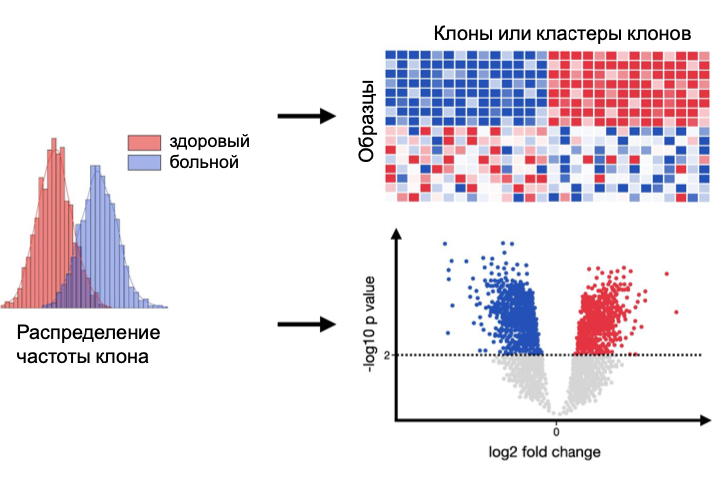

In [ ]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=edger_plot,
    x="logFC",
    y="minus_log10_FDR",
    hue="significant",
    palette={True: "red", False: "gray"},
    alpha=0.7,
    s=35,
    linewidth=0
)

plt.axvline(1, linestyle="--", color="black")
plt.axvline(-1, linestyle="--", color="black")
plt.axhline(-np.log10(0.05), linestyle="--", color="black")

plt.xlabel("log2 fold change: g1 против контроля")
plt.ylabel("-log10 FDR")
plt.title("edgeR: дифференциальная экспансия клонов")
plt.legend(title="FDR < 0.05")
plt.show()

по оси X: logFC  
это сила эффекта  
справа: клон обогащён в g1  
слева: клон обогащён в контроле  
по оси Y: -log10(FDR)  
это статистическая уверенность  
чем выше точка, тем надёжнее сигнал  
самые интересные клоны: правый верхний угол  

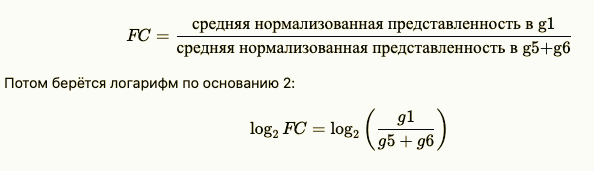

p-value:  
- H0: у этого feature нет систематической разницы между g1 и g5+g6
- H1: feature действительно сдвинут между g1 и контролем  
Если добавление эффекта группы сильно улучшает объяснение данных, p-value становится маленьким.

In [ ]:
top_labels = edger_plot.sort_values(["FDR", "logFC"], ascending=[True, False]).head(15).copy()

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=edger_plot,
    x="logFC",
    y="minus_log10_FDR",
    hue="significant",
    palette={True: "red", False: "gray"},
    alpha=0.7,
    s=35,
    linewidth=0,
    legend=False
)

plt.axvline(1, linestyle="--", color="black")
plt.axvline(-1, linestyle="--", color="black")
plt.axhline(-np.log10(0.05), linestyle="--", color="black")

for _, row in top_labels.iterrows():
    plt.text(
        row["logFC"],
        row["minus_log10_FDR"],
        str(row["feature_id"]),
        fontsize=8
    )

plt.xlabel("log2 fold change: g1 против контроля")
plt.ylabel("-log10 FDR")
plt.title("edgeR: топ наиболее значимых клонов")
plt.show()

по оси X: logCPM  
это средняя представленность клона  
левее: редкие клоны  
правее: более массовые клоны  
по оси Y: logFC  
насколько клон смещён в сторону g1 или контроля  
Он показывает, не построен ли весь результат только на редких клонах.  
Если значимые точки есть и среди умеренно или хорошо представленных клонов, это сильнее убеждает.  

In [ ]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=edger_plot,
    x="logCPM",
    y="logFC",
    hue="significant",
    palette={True: "red", False: "gray"},
    alpha=0.7,
    s=35,
    linewidth=0
)

plt.axhline(1, linestyle="--", color="black")
plt.axhline(-1, linestyle="--", color="black")

plt.xlabel("Средняя представленность клона: logCPM")
plt.ylabel("log2 fold change: g1 против контроля")
plt.title("edgeR: MA plot")
plt.legend(title="FDR < 0.05")
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=edger_plot,
    x="logCPM",
    y="logFC",
    hue="significant",
    palette={True: "red", False: "gray"},
    alpha=0.7,
    s=35,
    linewidth=0,
    legend=True
)

plt.axhline(1, linestyle="--", color="black")
plt.axhline(-1, linestyle="--", color="black")

# --- ВЫБОР ТОП КЛОНОВ ДЛЯ ПОДПИСИ ---
top_labels = (
    edger_plot
    .sort_values(["FDR", "logFC"], ascending=[True, False])
    .head(15)
)

# --- ДОБАВЛЕНИЕ ПОДПИСЕЙ ---
for _, row in top_labels.iterrows():
    plt.text(
        row["logCPM"],
        row["logFC"],
        str(row["feature_id"]),
        fontsize=8,
        alpha=0.9
    )

plt.xlabel("Средняя представленность клона: logCPM")
plt.ylabel("log2 fold change: g1 против контроля")
plt.title("edgeR: MA plot с подписями топ клонов")
plt.legend(title="FDR < 0.05")

plt.show()

In [ ]:
top_edger = (
    edger_plot[edger_plot["FDR"] < 0.05]
    .sort_values("logFC", ascending=False)
    .head(15)
    .copy()
)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_edger,
    y="feature_id",
    x="logFC"
)

plt.xlabel("log2 fold change: g1 против контроля")
plt.ylabel("Клон aaV")
plt.title("edgeR: топ клонов, обогащённых в g1")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

edger_plot = edgeR_res_g1.copy()

# если feature_id хранится как tuple-like строка
edger_plot["feature_str"] = edger_plot["feature_id"].astype(str)

parsed = edger_plot["feature_str"].str.extract(r"\('?(.*?)'?,\s*'?(.*?)'?\)")
edger_plot["cdr3aa"] = parsed[0]
edger_plot["v_gene"] = parsed[1]

display(edger_plot[["feature_id", "cdr3aa", "v_gene", "logFC", "FDR"]].head())

In [ ]:
v_summary = (
    edger_plot[edger_plot["FDR"] < 0.05]
    .groupby("v_gene")
    .agg(
        n_signif_features=("feature_id", "count"),
        mean_logFC=("logFC", "mean"),
        max_logFC=("logFC", "max")
    )
    .reset_index()
)

# можно отфильтровать V-сегменты, где хотя бы 2 значимых aaV-feature
v_summary = v_summary[v_summary["n_signif_features"] >= 2].copy()

top_v = (
    v_summary
    .sort_values(["mean_logFC", "n_signif_features"], ascending=[False, False])
    .head(15)
)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_v,
    y="v_gene",
    x="mean_logFC"
)

plt.xlabel("Средний log2 fold change значимых aaV-feature")
plt.ylabel("V-сегмент")
plt.title("edgeR: топ V-сегментов, обогащённых в g1")
plt.show()

In [ ]:
top_v_count = (
    v_summary
    .sort_values(["n_signif_features", "mean_logFC"], ascending=[False, False])
    .head(15)
)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_v_count,
    y="v_gene",
    x="n_signif_features"
)

plt.xlabel("Число значимых aaV-feature")
plt.ylabel("V-сегмент")
plt.title("edgeR: V-сегменты с наибольшим числом значимых feature в g1")
plt.show()

1: средний log2FC среди значимых aaV-feature
Это график, где выше всех TRAV4-2.

Интерпретация такая:
среди V-генов, у которых есть значимые aaV-feature, именно у TRAV4-2 в среднем самые сильные сдвиги в сторону g1. То есть его signal strength максимален. Это аргумент в пользу того, что TRAV4-2 связан с наиболее сильным обогащением, но не обязательно с самым массовым ответом.

2: число значимых aaV-feature
Это график, где выше всех TRAV7D-3, дальше TRAV6-6, потом TRAV13-1.

Интерпретация такая:
у TRAV7D-3 больше всего значимых aaV-feature, то есть этот V-ген чаще других встречается среди feature, обогащённых в g1. Это аргумент в пользу того, что он наиболее широко представлен в аллогенно смещённом репертуаре.

Отсюда правильный вывод такой:

по силе эффекта главный кандидат: TRAV4-2
по числу значимых feature главный кандидат: TRAV7D-3
наиболее устойчиво повторяющийся сильный кандидат на глаз: TRAV6-6, потому что он высок и по среднему эффекту, и по числу значимых feature

### DESeq2

Если мало данных то обычный MLE нестабилен  
DESeq2 апроксимирует оценки к среднему

Меньше FP, но может не заметить слабый TP

In [ ]:
ro.globalenv["countData"] = pandas2ri.py2rpy(countData_g1)
ro.globalenv["coldata"] = pandas2ri.py2rpy(coldata_g1.reset_index(drop=True))

ro.r("""
library(DESeq2)

dds <- DESeqDataSetFromMatrix(
    countData = countData,
    colData = coldata,
    design = ~ group_simple
)

keep <- rowSums(counts(dds)) > 1
dds <- dds[keep, ]

dds <- DESeq(dds)
res <- results(dds, contrast=c("group_simple", "g1", "ctrl"))
deseq_table <- as.data.frame(res)
""")

deseq_res_g1 = pandas2ri.rpy2py(ro.globalenv["deseq_table"])
deseq_res_g1["feature_id"] = deseq_res_g1.index
deseq_res_g1 = deseq_res_g1.reset_index(drop=True)

display(deseq_res_g1.head())

### Сравнение Fisher, EdgeR, DESeq2

In [ ]:
# Fisher table в удобный вид
fisher_compare_g1 = fisher_df.reset_index().rename(columns={"index": "feature_id"})[
    ["feature_id", "Fisher_log2FC_g1", "Fisher_p_g1", "Fisher_FDR_g1"]
].copy()

# edgeR и DESeq2 подгоним имена
edgeR_compare_g1 = edgeR_res_g1.rename(columns={
    "logFC": "edgeR_log2FC_g1",
    "PValue": "edgeR_p_g1",
    "FDR": "edgeR_FDR_g1"
})[["feature_id", "edgeR_log2FC_g1", "edgeR_p_g1", "edgeR_FDR_g1"]].copy()

deseq_compare_g1 = deseq_res_g1.rename(columns={
    "log2FoldChange": "DESeq2_log2FC_g1",
    "pvalue": "DESeq2_p_g1",
    "padj": "DESeq2_FDR_g1"
})[["feature_id", "DESeq2_log2FC_g1", "DESeq2_p_g1", "DESeq2_FDR_g1"]].copy()

comparison_g1 = (
    fisher_compare_g1
    .merge(edgeR_compare_g1, on="feature_id", how="inner")
    .merge(deseq_compare_g1, on="feature_id", how="inner")
)

display(comparison_g1.head())
print(comparison_g1.shape)

### Сравнение pairplot

In [ ]:
plot_df = comparison_g1[[
    "Fisher_log2FC_g1",
    "edgeR_log2FC_g1",
    "DESeq2_log2FC_g1"
]].replace([np.inf, -np.inf], np.nan).dropna()

sns.pairplot(plot_df)
plt.suptitle("Сравнение log2FC между Fisher, edgeR и DESeq2: g1 против контроля", y=1.02)
plt.show()

###  Топ консенсусных

In [ ]:
consensus_g1 = comparison_g1[
    (comparison_g1["Fisher_FDR_g1"] < 0.05) &
    (comparison_g1["edgeR_FDR_g1"] < 0.05) &
    (comparison_g1["DESeq2_FDR_g1"] < 0.05)
].copy()

consensus_g1["mean_log2FC"] = consensus_g1[
    ["Fisher_log2FC_g1", "edgeR_log2FC_g1", "DESeq2_log2FC_g1"]
].mean(axis=1)

consensus_g1 = consensus_g1.sort_values("mean_log2FC", ascending=False)

display(consensus_g1.head(30))